# Load libraries

In [18]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn seaborn umap-learn scipy xgboost shap PyALE


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip3 install --upgrade pip


In [19]:
import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns
import math
import json
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor  # Changed from XGBRegressor
from sklearn.preprocessing import StandardScaler  # Add this - important for MLPs!
from sklearn.metrics import root_mean_squared_error, r2_score
import shap
from PyALE import ale
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.stats import linregress, spearmanr

# Loading the data

In [47]:
chamau_lag = pd.read_csv("../datasets/Chamau_2014-2024_clean_newlag.csv")
chamau_daily = pd.read_csv("../datasets/Chamau_Daily_2014-2024_newlag.csv")
oensingen_1_lag = pd.read_csv("../datasets/Oensingen_2018-19_clean_newlag.csv")
oensingen_1_daily = pd.read_csv("../datasets/Oensingen_Daily_2018-19_newlag.csv")
oensingen_2_lag = pd.read_csv("../datasets/Oensingen_2021-23_clean_newlag.csv")
oensingen_2_daily = pd.read_csv("../datasets/Oensingen_Daily_2021-23_newlag.csv")
aeschi_lag = pd.read_csv("../datasets/Aeschi_2019-20_clean_newlag.csv")
aeschi_daily = pd.read_csv("../datasets/Aeschi_Daily_2019-20_newlag.csv")
forel_lag = pd.read_csv("../datasets/Forel_2024-25_clean_newlag.csv")
forel_daily = pd.read_csv("../datasets/Forel_Daily_2024-25_newlag.csv")
tanikon_lag = pd.read_csv("../datasets/Tanikon_2023-25_clean_newlag.csv")
tanikon_daily = pd.read_csv("../datasets/Tanikon_Daily_2023-25_newlag.csv")

# Model setup

In [37]:
def train_mlp_timeseries(df, predictors, target, test_size=0.1, 
                         random_state=42, plot=True):
    """
    Train MLP on time-series data using chronological split.
    
    Includes feature scaling (essential for MLPs) and time series comparison plot.
    """
    
    # EXTRACT FEATURES/TARGET
    X = df[predictors]
    y = df[target]
    
    # HANDLE NaNs
    mask = X.notna().all(axis=1) & y.notna()
    X, y = X[mask], y[mask]
    
    # OFFSET FOR POSITIVITY (if needed for your target)
    offset = abs(y.min()) + 1e-6 if y.min() < 0 else 0
    y_shifted = y + offset
    
    # CHRONOLOGICAL SPLIT
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y_shifted.iloc[:split_idx], y_shifted.iloc[split_idx:]
    
    # Store test dates for time series plot
    test_dates = X_test.index
    
    time_train = (df.index.min(), df.index[:split_idx].max())
    time_test = (df.index[split_idx], df.index.max())
    
    print(f"Train period: {time_train[0]} → {time_train[1]}")
    print(f"Test  period: {time_test[0]} → {time_test[1]}")
    
    # FEATURE SCALING (CRITICAL FOR MLPs!)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # TRAIN MODEL
    model = MLPRegressor(
        hidden_layer_sizes=(150, 100, 50),  # Deeper for complex patterns
        activation='relu',
        solver='adam',
        alpha=0.001,  # Stronger regularization
        batch_size=32,  # Explicit batch size
        learning_rate='adaptive',
        learning_rate_init=0.001,
        max_iter=2000,  # More iterations
        random_state=random_state,
        early_stopping=True,
        validation_fraction=0.15,  # More validation data
        n_iter_no_change=30,  # More patience
        tol=1e-5,  # Stricter convergence
    )
    
    print("\nTraining MLP...")
    model.fit(X_train_scaled, y_train)
    print(f"Training stopped at iteration: {model.n_iter_}")
    
    # PREDICTIONS
    y_pred = model.predict(X_test_scaled)
    
    # REVERT OFFSET
    y_pred_lin = y_pred - offset
    y_test_lin = y_test - offset
    
    # EVALUATION
    r2 = r2_score(y_test_lin, y_pred_lin)
    rho, _ = spearmanr(y_test_lin, y_pred_lin)
    
    # FEATURE IMPORTANCE (approximation using absolute weights from first layer)
    # For MLPs, this is less interpretable than tree-based models
    first_layer_weights = np.abs(model.coefs_[0]).mean(axis=1)
    importances = pd.Series(first_layer_weights, index=predictors).sort_values(ascending=False)
    
    print("\nModel evaluation:")
    print(f"  R² (linear scale): {r2:.3f}")
    print(f"  Spearman ρ:        {rho:.3f}")
    
    # PLOT
    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # 1. Scatter plot
        axes[0].scatter(y_test_lin, y_pred_lin, alpha=0.6, s=20)
        min_val, max_val = y_test_lin.min(), y_test_lin.max()
        axes[0].plot([min_val, max_val], [min_val, max_val], "r--", lw=2)
        axes[0].set_xlabel("Observed N₂O Flux")
        axes[0].set_ylabel("Predicted N₂O Flux")
        axes[0].set_title(f"MLP (R²={r2:.3f}, ρ={rho:.3f})")
        axes[0].grid(True, alpha=0.3)
        
        # 2. Feature importance (approximate)
        top_features = importances.head(15)
        axes[1].barh(range(len(top_features)), top_features.values)
        axes[1].set_yticks(range(len(top_features)))
        axes[1].set_yticklabels(top_features.index)
        axes[1].set_xlabel("Avg Absolute Weight")
        axes[1].set_title("Top 15 Features (approx)")
        axes[1].invert_yaxis()
        
        # 3. TIME SERIES COMPARISON
        axes[2].plot(test_dates, y_test_lin.values, label="Observed", color="black", lw=1.5)
        axes[2].plot(test_dates, y_pred_lin, label="Predicted", color="royalblue", lw=1.5, alpha=0.8)
        axes[2].set_xlabel("Date")
        axes[2].set_ylabel("N₂O Flux")
        axes[2].set_title("Time Series Comparison")
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        
        plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        plt.tight_layout()
        plt.show()
    
    return {
        "model": model,
        "scaler": scaler,  # Return scaler - you'll need it for future predictions!
        "r2": r2,
        "spearman_rho": rho,
        "feature_importance": importances,
        "y_test": y_test_lin,
        "y_pred": y_pred_lin,
        "test_dates": test_dates,
    }

# Experiment 1: Chamau

In [38]:
# FIX TIMESTAMP
chamau_lag['Timestamp'] = pd.to_datetime(chamau_lag['Timestamp'])
chamau_lag = chamau_lag.set_index('Timestamp').sort_index()

chamau_daily['Date'] = pd.to_datetime(chamau_daily['Date'])
chamau_daily = chamau_daily.set_index('Date').sort_index()

EXPERIMENT 1: Chamau 2014-2024

--- HOURLY | target=N2O_Flux_ln | predictors=BASE ---
Train period: 2014-01-01 08:15:00 → 2021-07-31 12:15:00
Test  period: 2021-07-31 13:15:00 → 2022-07-06 09:15:00

Training MLP...
Training stopped at iteration: 210

Model evaluation:
  R² (linear scale): 0.142
  Spearman ρ:        0.322


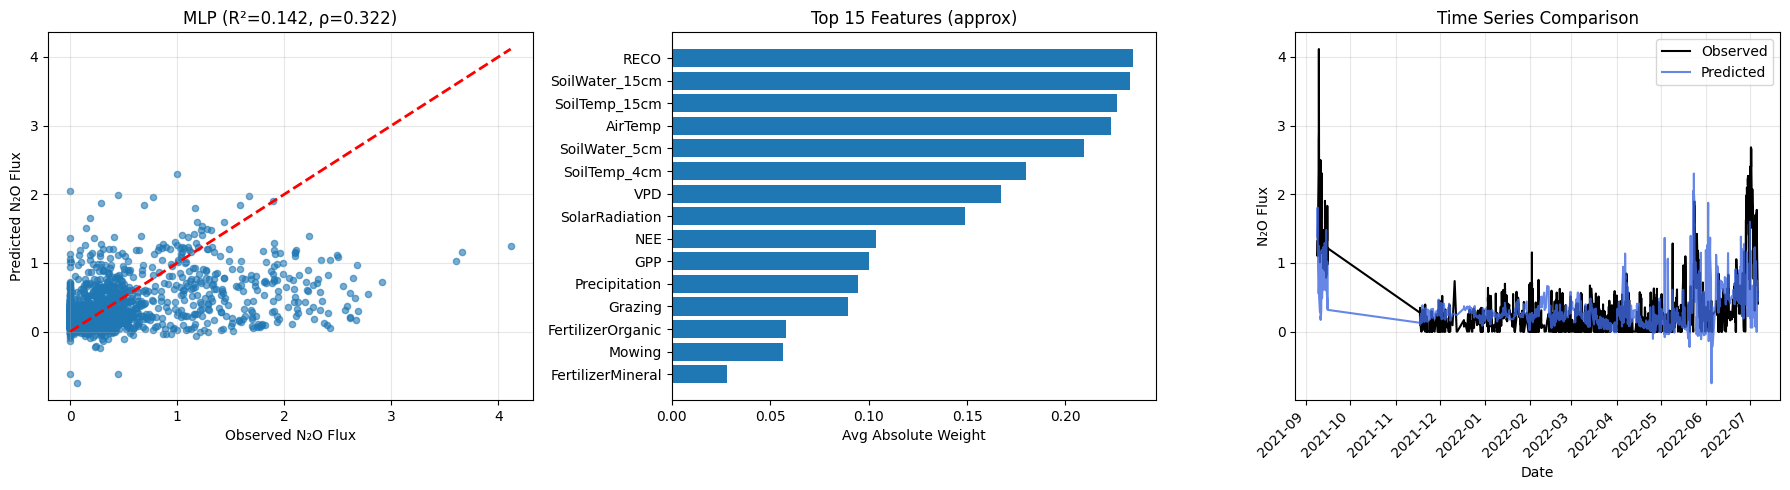


--- HOURLY | target=N2O_Flux_ln | predictors=LAG ---
Train period: 2014-01-01 08:15:00 → 2021-06-29 15:45:00
Test  period: 2021-06-29 17:15:00 → 2022-07-06 09:15:00

Training MLP...
Training stopped at iteration: 76

Model evaluation:
  R² (linear scale): 0.111
  Spearman ρ:        0.286


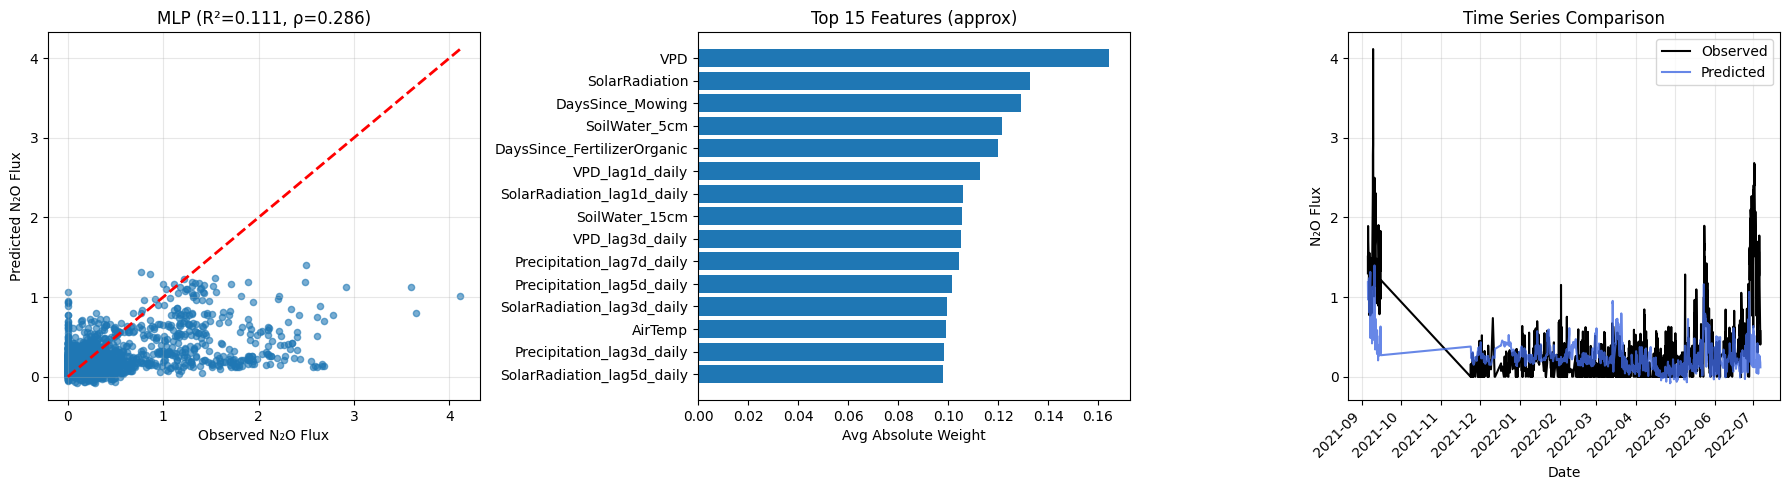


--- HOURLY | target=N2O_Flux_ln | predictors=AUGMENTED ---
Train period: 2014-01-01 08:15:00 → 2021-06-29 15:45:00
Test  period: 2021-06-29 17:15:00 → 2022-07-06 09:15:00

Training MLP...
Training stopped at iteration: 77

Model evaluation:
  R² (linear scale): 0.080
  Spearman ρ:        0.246


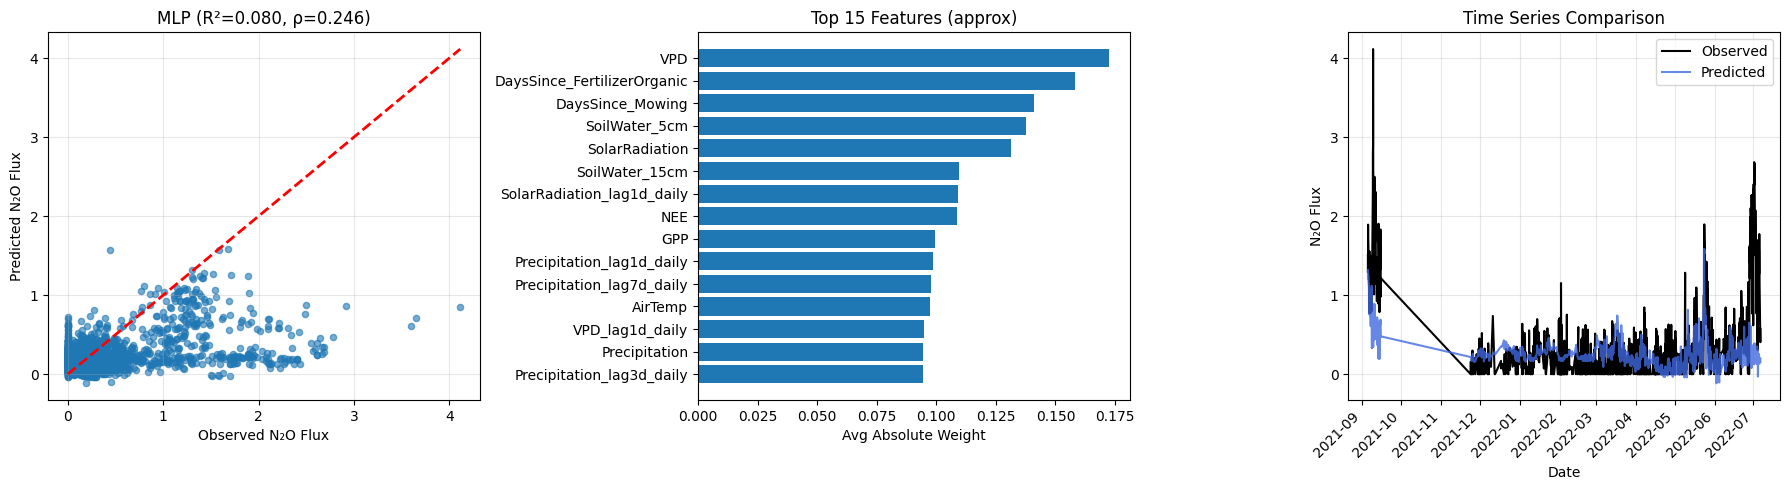


--- DAILY | target=N2O_Flux_ln | predictors=BASE ---
Train period: 2014-01-01 00:00:00 → 2021-08-10 00:00:00
Test  period: 2021-08-10 00:00:00 → 2022-07-06 00:00:00

Training MLP...
Training stopped at iteration: 63

Model evaluation:
  R² (linear scale): -0.327
  Spearman ρ:        0.334


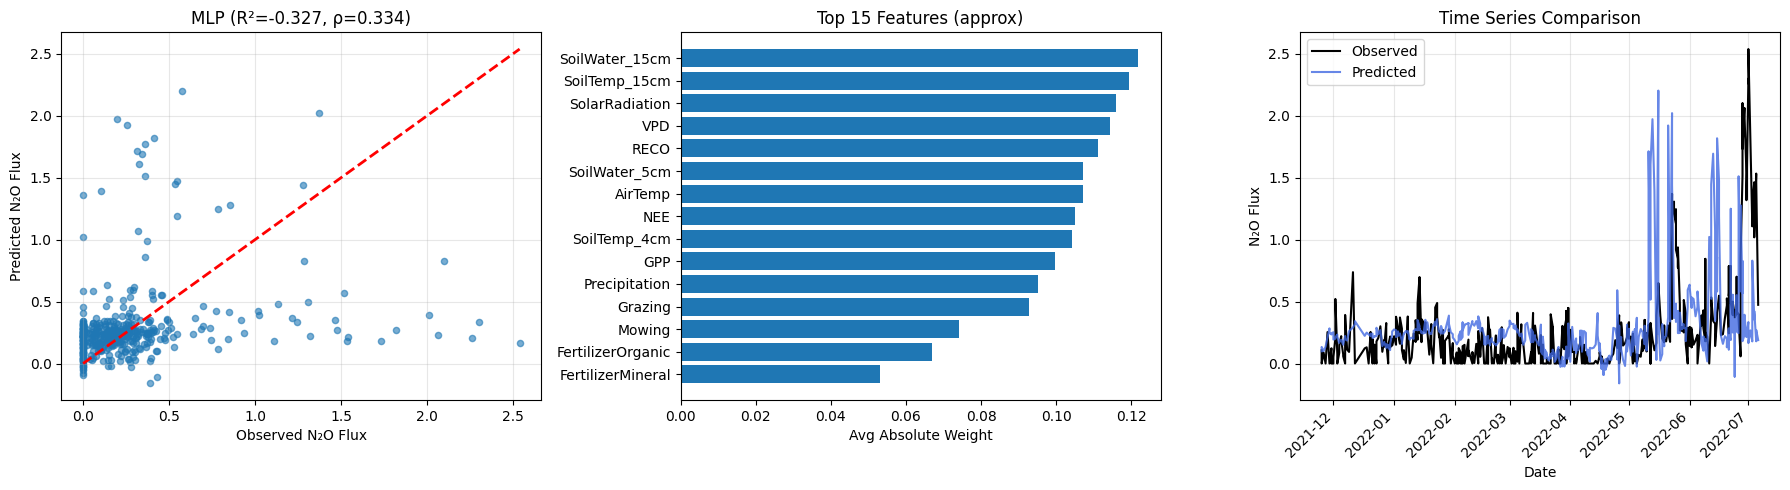


--- DAILY | target=N2O_Flux_ln | predictors=LAG ---
Train period: 2014-01-01 00:00:00 → 2021-07-22 00:00:00
Test  period: 2021-07-23 00:00:00 → 2022-07-06 00:00:00

Training MLP...
Training stopped at iteration: 81

Model evaluation:
  R² (linear scale): 0.096
  Spearman ρ:        0.259


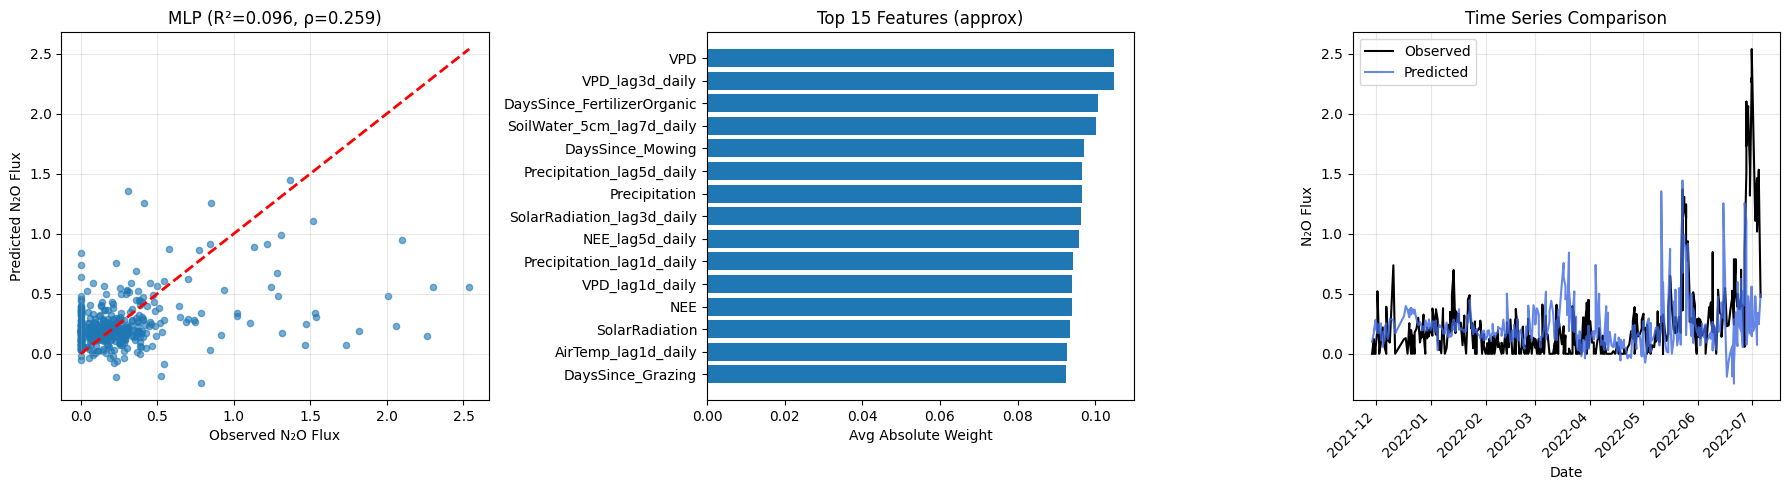


--- DAILY | target=N2O_Flux_ln | predictors=AUGMENTED ---
Train period: 2014-01-01 00:00:00 → 2021-07-22 00:00:00
Test  period: 2021-07-23 00:00:00 → 2022-07-06 00:00:00

Training MLP...
Training stopped at iteration: 140

Model evaluation:
  R² (linear scale): 0.274
  Spearman ρ:        0.377


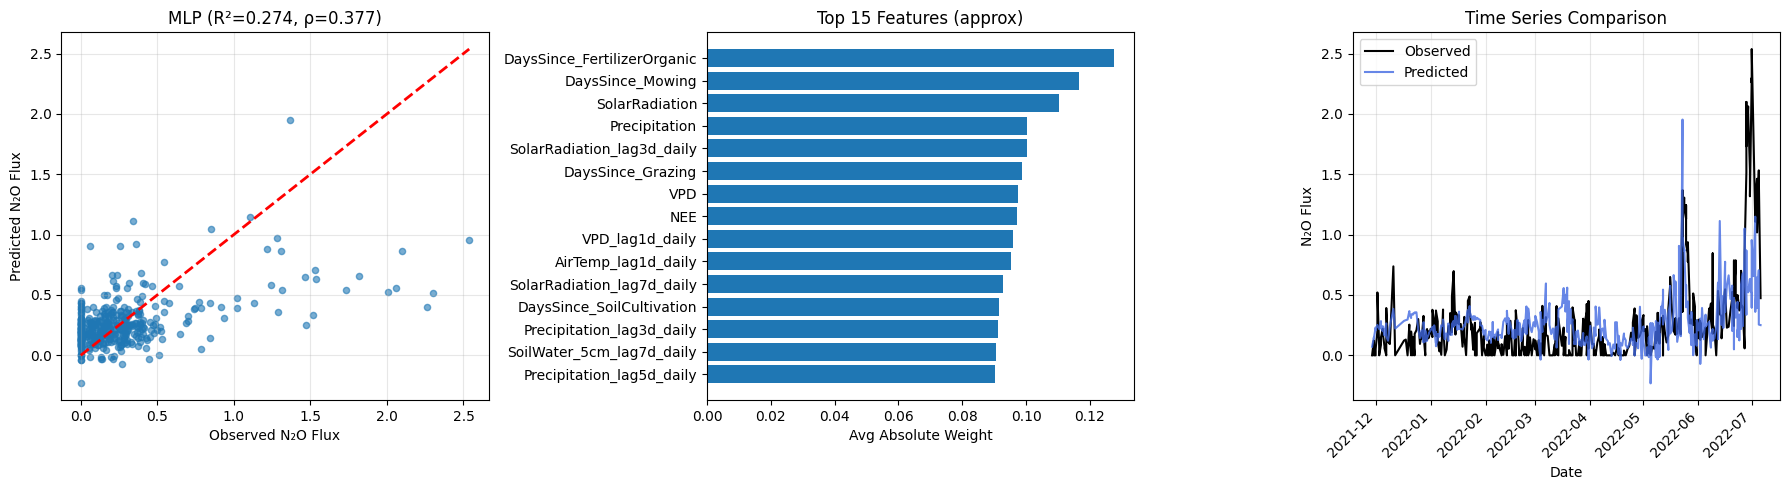


COMPREHENSIVE COMPARISON OF ALL EXPERIMENTS:
Temporal     Predictors   R²       Spearman ρ  
--------------------------------------------------------------------------------
Hourly       Base          0.142        0.322
Hourly       Lag           0.111        0.286
Hourly       Augmented     0.080        0.246
Daily        Base         -0.327        0.334
Daily        Lag           0.096        0.259
Daily        Augmented     0.274        0.377

IMPROVEMENT FROM BASE TO LAG:
Hourly: R² + -0.031, ρ + -0.035
Daily:  R² +  0.423, ρ + -0.075

IMPROVEMENT FROM LAG TO AUGMENTED:
Hourly: R² + -0.031, ρ + -0.041
Daily:  R² +  0.178, ρ +  0.118


In [39]:
# ============================================================================
# CHAMAU
# ============================================================================

print("="*80)
print("EXPERIMENT 1: Chamau 2014-2024")
print("="*80)

# Define base and lag predictors
base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm",
    "SoilTemp_4cm", "SoilTemp_15cm",
    "NEE", "GPP", "RECO",
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "Grazing", "SoilCultivation"
]

lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm",
    "SoilTemp_4cm", "SoilTemp_15cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilTemp_4cm_lag1d_daily", "SoilTemp_4cm_lag3d_daily", "SoilTemp_4cm_lag5d_daily", "SoilTemp_4cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",

    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "Grazing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_Grazing", "DaysSince_SoilCultivation"
]

augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilTemp_4cm", "SoilTemp_15cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilTemp_4cm_lag1d_daily", "SoilTemp_4cm_lag3d_daily", "SoilTemp_4cm_lag5d_daily", "SoilTemp_4cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilTemp_4cm_roll3d_mean", "SoilTemp_4cm_roll5d_mean", "SoilTemp_4cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilTemp_4cm_roll3d_sum", "SoilTemp_4cm_roll5d_sum", "SoilTemp_4cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "Grazing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_Grazing", "DaysSince_SoilCultivation"
]

# Store results for comparison
all_results = []

# ============================================================================
# HOURLY DATA - BASE PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=BASE ---")
print("="*80)

results_hourly_base = train_mlp_timeseries(
    df=chamau_lag,
    predictors=base_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Base", results_hourly_base['r2'], results_hourly_base['spearman_rho']))


# ============================================================================
# HOURLY DATA - LAG PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=LAG ---")
print("="*80)

results_hourly_lag = train_mlp_timeseries(
    df=chamau_lag,
    predictors=lag_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Lag", results_hourly_lag['r2'], results_hourly_lag['spearman_rho']))


# ============================================================================
# HOURLY DATA - AUGMENTED PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=AUGMENTED ---")
print("="*80)

results_hourly_augmented = train_mlp_timeseries(
    df=chamau_lag,
    predictors=augmented_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Augmented", results_hourly_augmented['r2'], results_hourly_augmented['spearman_rho']))

# ============================================================================
# DAILY DATA - BASE PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=BASE ---")
print("="*80)

results_daily_base = train_mlp_timeseries(
    df=chamau_daily,
    predictors=base_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Base", results_daily_base['r2'], results_daily_base['spearman_rho']))

# ============================================================================
# DAILY DATA - LAG PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=LAG ---")
print("="*80)

results_daily_lag = train_mlp_timeseries(
    df=chamau_daily,
    predictors=lag_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Lag", results_daily_lag['r2'], results_daily_lag['spearman_rho']))


# ============================================================================
# DAILY DATA - AUGMENTED PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=AUGMENTED ---")
print("="*80)

results_daily_augmented = train_mlp_timeseries(
    df=chamau_daily,
    predictors=augmented_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Augmented", results_daily_augmented['r2'], results_daily_augmented['spearman_rho']))

# ============================================================================
# COMPREHENSIVE COMPARISON
# ============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON OF ALL EXPERIMENTS:")
print("="*80)
print(f"{'Temporal':<12} {'Predictors':<12} {'R²':<8} {'Spearman ρ':<12}")
print("-"*80)
for temp, pred, r2, rho in all_results:
    print(f"{temp:<12} {pred:<12} {r2:>6.3f}   {rho:>10.3f}")

print("\n" + "="*80)
print("IMPROVEMENT FROM BASE TO LAG:")
print("="*80)
print(f"Hourly: R² + {(results_hourly_lag['r2'] - results_hourly_base['r2']):>6.3f}, ρ + {(results_hourly_lag['spearman_rho'] - results_hourly_base['spearman_rho']):>6.3f}")
print(f"Daily:  R² + {(results_daily_lag['r2'] - results_daily_base['r2']):>6.3f}, ρ + {(results_daily_lag['spearman_rho'] - results_daily_base['spearman_rho']):>6.3f}")

print("\n" + "="*80)
print("IMPROVEMENT FROM LAG TO AUGMENTED:")
print("="*80)
print(f"Hourly: R² + {(results_hourly_augmented['r2'] - results_hourly_lag['r2']):>6.3f}, ρ + {(results_hourly_augmented['spearman_rho'] - results_hourly_lag['spearman_rho']):>6.3f}")
print(f"Daily:  R² + {(results_daily_augmented['r2'] - results_daily_lag['r2']):>6.3f}, ρ + {(results_daily_augmented['spearman_rho'] - results_daily_lag['spearman_rho']):>6.3f}")

# Experiment 2: Forel

In [40]:
# FIX TIMESTAMP
forel_lag['Timestamp'] = pd.to_datetime(forel_lag['Timestamp'])
forel_lag = forel_lag.set_index('Timestamp').sort_index()

forel_daily['Date'] = pd.to_datetime(forel_daily['Date'])
forel_daily = forel_daily.set_index('Date').sort_index()

EXPERIMENT 2: Forel 2024-2025

--- HOURLY | target=N2O_Flux_ln | predictors=BASE ---
Train period: 2024-03-07 21:15:00 → 2025-03-01 19:15:00
Test  period: 2025-03-01 19:45:00 → 2025-05-03 13:15:00

Training MLP...
Training stopped at iteration: 104

Model evaluation:
  R² (linear scale): 0.157
  Spearman ρ:        0.455


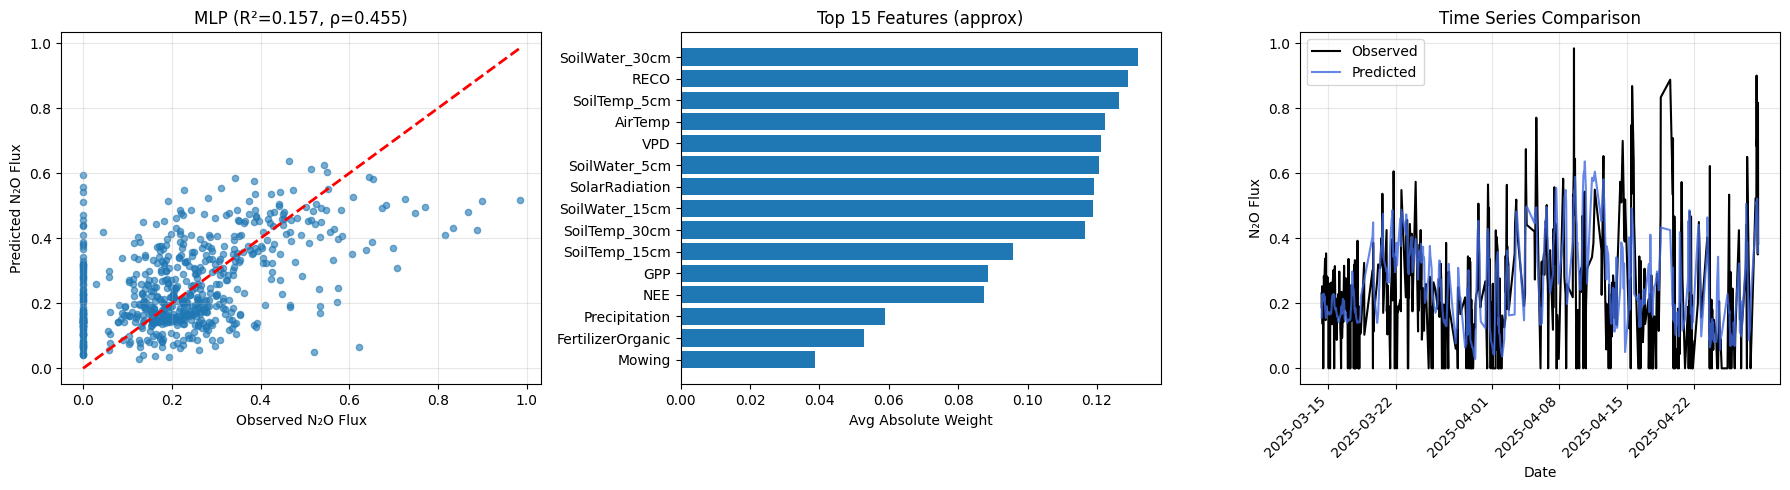


--- HOURLY | target=N2O_Flux_ln | predictors=LAG ---
Train period: 2024-03-07 21:15:00 → 2025-02-17 21:15:00
Test  period: 2025-02-18 03:15:00 → 2025-05-03 13:15:00

Training MLP...
Training stopped at iteration: 102

Model evaluation:
  R² (linear scale): 0.190
  Spearman ρ:        0.376


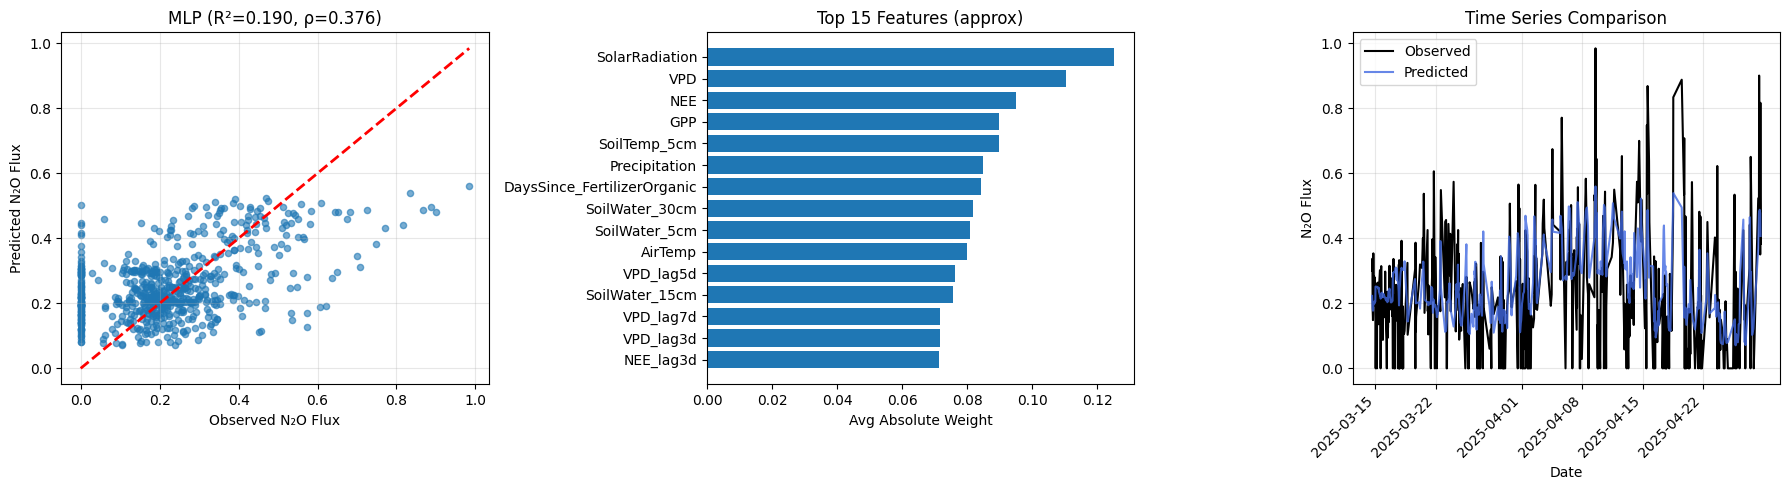


--- HOURLY | target=N2O_Flux_ln | predictors=AUGMENTED ---
Train period: 2024-03-07 21:15:00 → 2025-02-17 21:15:00
Test  period: 2025-02-18 03:15:00 → 2025-05-03 13:15:00

Training MLP...
Training stopped at iteration: 150

Model evaluation:
  R² (linear scale): 0.312
  Spearman ρ:        0.485


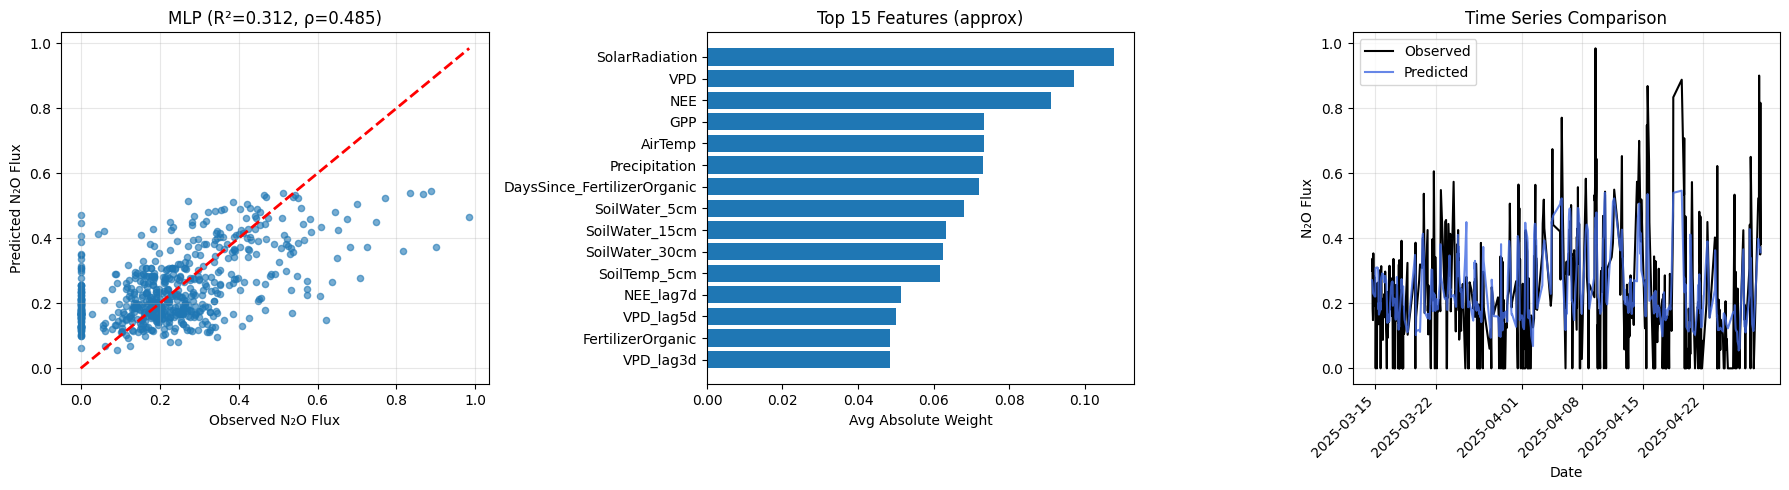


--- DAILY | target=N2O_Flux_ln | predictors=BASE ---
Train period: 2024-03-07 00:00:00 → 2025-03-11 00:00:00
Test  period: 2025-03-12 00:00:00 → 2025-05-03 00:00:00

Training MLP...
Training stopped at iteration: 64

Model evaluation:
  R² (linear scale): -0.655
  Spearman ρ:        0.151


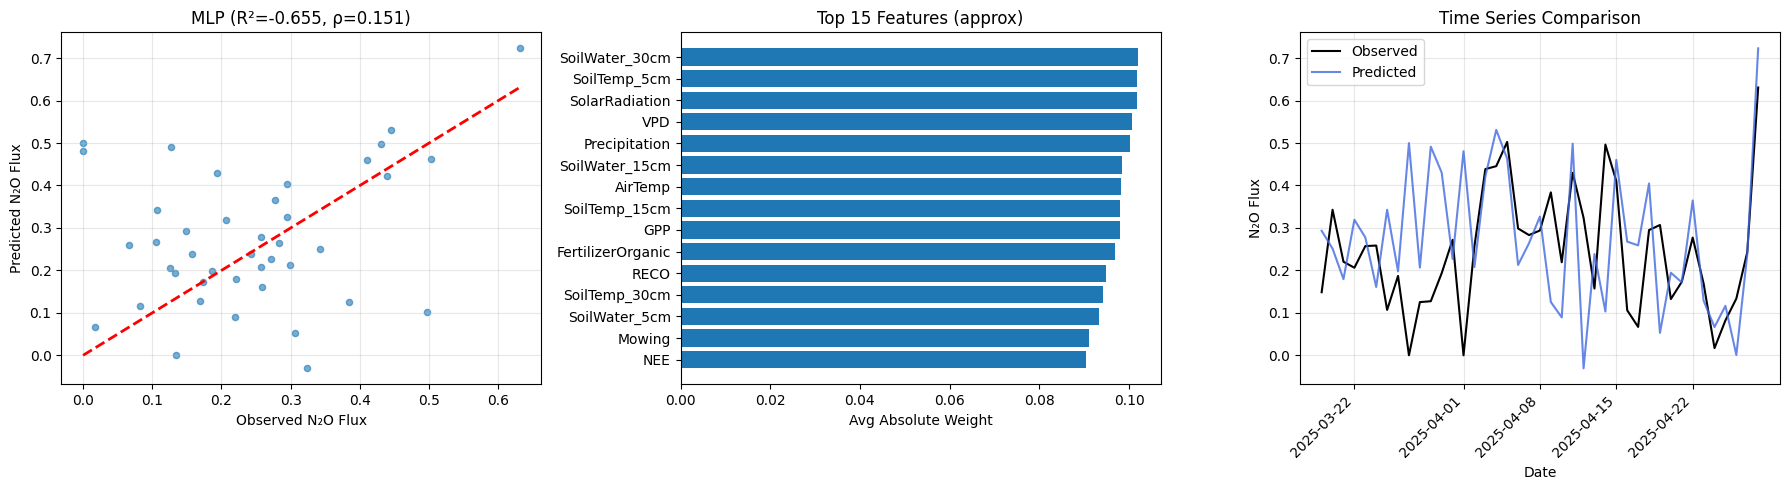


--- DAILY | target=N2O_Flux_ln | predictors=LAG ---
Train period: 2024-03-07 00:00:00 → 2025-03-05 00:00:00
Test  period: 2025-03-06 00:00:00 → 2025-05-03 00:00:00

Training MLP...
Training stopped at iteration: 83

Model evaluation:
  R² (linear scale): 0.057
  Spearman ρ:        0.452


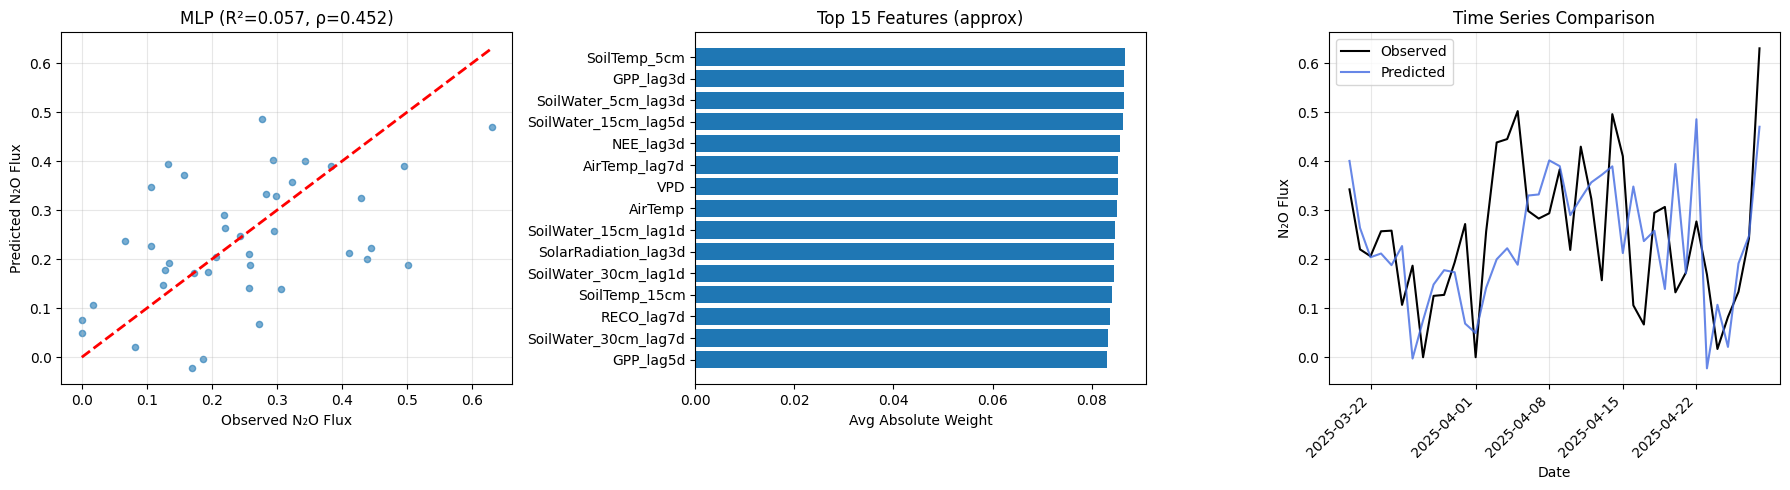


--- DAILY | target=N2O_Flux_ln | predictors=AUGMENTED ---
Train period: 2024-03-07 00:00:00 → 2025-03-05 00:00:00
Test  period: 2025-03-06 00:00:00 → 2025-05-03 00:00:00

Training MLP...
Training stopped at iteration: 54

Model evaluation:
  R² (linear scale): -0.032
  Spearman ρ:        0.364


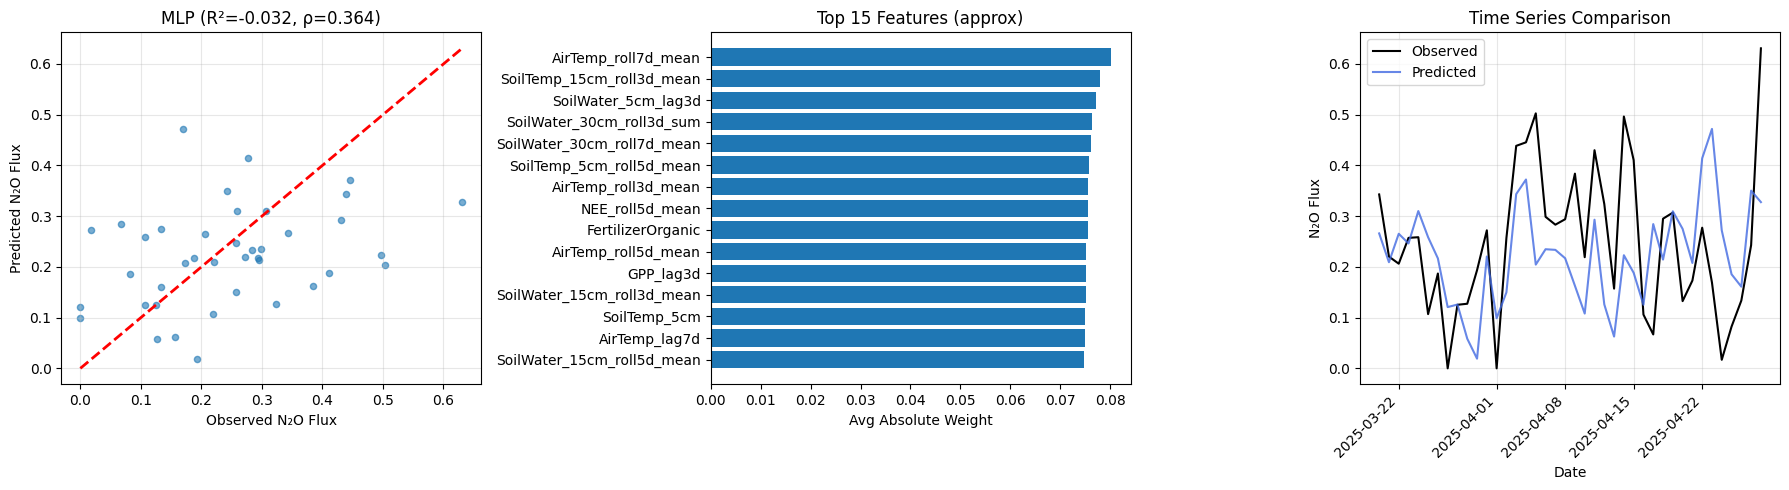


COMPREHENSIVE COMPARISON OF ALL EXPERIMENTS:
Temporal     Predictors   R²       Spearman ρ  
--------------------------------------------------------------------------------
Hourly       Base          0.157        0.455
Hourly       Lag           0.190        0.376
Hourly       Augmented     0.312        0.485
Daily        Base         -0.655        0.151
Daily        Lag           0.057        0.452
Daily        Augmented    -0.032        0.364

IMPROVEMENT FROM BASE TO LAG:
Hourly: R² +  0.033, ρ + -0.079
Daily:  R² +  0.712, ρ +  0.302

IMPROVEMENT FROM LAG TO AUGMENTED:
Hourly: R² +  0.122, ρ +  0.109
Daily:  R² + -0.090, ρ + -0.088


In [41]:
# ============================================================================
# FOREL
# ============================================================================

print("="*80)
print("EXPERIMENT 2: Forel 2024-2025")
print("="*80)

# Define base and lag predictors
base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    "Mowing", "FertilizerOrganic", "FertilizerMineral",
]

lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",

    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
]

augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # Management events and days since
    "Mowing", "FertilizerOrganic", "FertilizerMineral",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
]

# Store results for comparison
all_results = []

# ============================================================================
# HOURLY DATA - BASE PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=BASE ---")
print("="*80)

results_hourly_base = train_mlp_timeseries(
    df=forel_lag,
    predictors=base_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Base", results_hourly_base['r2'], results_hourly_base['spearman_rho']))


# ============================================================================
# HOURLY DATA - LAG PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=LAG ---")
print("="*80)

results_hourly_lag = train_mlp_timeseries(
    df=forel_lag,
    predictors=lag_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Lag", results_hourly_lag['r2'], results_hourly_lag['spearman_rho']))


# ============================================================================
# HOURLY DATA - AUGMENTED PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=AUGMENTED ---")
print("="*80)

results_hourly_augmented = train_mlp_timeseries(
    df=forel_lag,
    predictors=augmented_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Augmented", results_hourly_augmented['r2'], results_hourly_augmented['spearman_rho']))

# ============================================================================
# DAILY DATA - BASE PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=BASE ---")
print("="*80)

results_daily_base = train_mlp_timeseries(
    df=forel_daily,
    predictors=base_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Base", results_daily_base['r2'], results_daily_base['spearman_rho']))

# ============================================================================
# DAILY DATA - LAG PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=LAG ---")
print("="*80)

results_daily_lag = train_mlp_timeseries(
    df=forel_daily,
    predictors=lag_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Lag", results_daily_lag['r2'], results_daily_lag['spearman_rho']))


# ============================================================================
# DAILY DATA - AUGMENTED PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=AUGMENTED ---")
print("="*80)

results_daily_augmented = train_mlp_timeseries(
    df=forel_daily,
    predictors=augmented_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Augmented", results_daily_augmented['r2'], results_daily_augmented['spearman_rho']))

# ============================================================================
# COMPREHENSIVE COMPARISON
# ============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON OF ALL EXPERIMENTS:")
print("="*80)
print(f"{'Temporal':<12} {'Predictors':<12} {'R²':<8} {'Spearman ρ':<12}")
print("-"*80)
for temp, pred, r2, rho in all_results:
    print(f"{temp:<12} {pred:<12} {r2:>6.3f}   {rho:>10.3f}")

print("\n" + "="*80)
print("IMPROVEMENT FROM BASE TO LAG:")
print("="*80)
print(f"Hourly: R² + {(results_hourly_lag['r2'] - results_hourly_base['r2']):>6.3f}, ρ + {(results_hourly_lag['spearman_rho'] - results_hourly_base['spearman_rho']):>6.3f}")
print(f"Daily:  R² + {(results_daily_lag['r2'] - results_daily_base['r2']):>6.3f}, ρ + {(results_daily_lag['spearman_rho'] - results_daily_base['spearman_rho']):>6.3f}")

print("\n" + "="*80)
print("IMPROVEMENT FROM LAG TO AUGMENTED:")
print("="*80)
print(f"Hourly: R² + {(results_hourly_augmented['r2'] - results_hourly_lag['r2']):>6.3f}, ρ + {(results_hourly_augmented['spearman_rho'] - results_hourly_lag['spearman_rho']):>6.3f}")
print(f"Daily:  R² + {(results_daily_augmented['r2'] - results_daily_lag['r2']):>6.3f}, ρ + {(results_daily_augmented['spearman_rho'] - results_daily_lag['spearman_rho']):>6.3f}")

# Experiment 3: Tanikon

In [42]:
# FIX TIMESTAMP
tanikon_lag['Timestamp'] = pd.to_datetime(tanikon_lag['Timestamp'])
tanikon_lag = tanikon_lag.set_index('Timestamp').sort_index()

tanikon_daily['Date'] = pd.to_datetime(tanikon_daily['Date'])
tanikon_daily = tanikon_daily.set_index('Date').sort_index()

EXPERIMENT 3: Tanikon 2023-2025

--- HOURLY | target=N2O_Flux_ln | predictors=BASE ---
Train period: 2023-11-07 15:45:00 → 2025-02-17 03:45:00
Test  period: 2025-02-17 04:15:00 → 2025-06-05 00:45:00

Training MLP...
Training stopped at iteration: 190

Model evaluation:
  R² (linear scale): -29.489
  Spearman ρ:        0.030


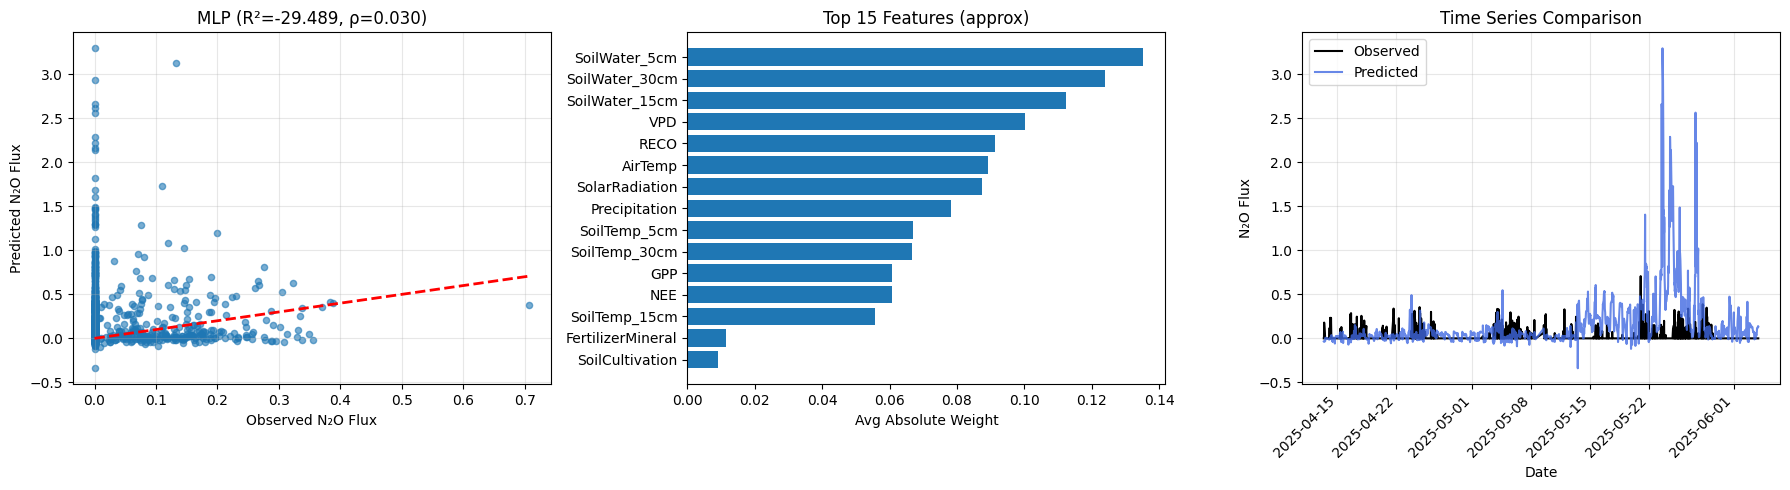


--- HOURLY | target=N2O_Flux_ln | predictors=LAG ---
Train period: 2023-11-07 15:45:00 → 2025-01-30 12:15:00
Test  period: 2025-01-30 12:45:00 → 2025-06-05 00:45:00

Training MLP...
Training stopped at iteration: 47

Model evaluation:
  R² (linear scale): -25.081
  Spearman ρ:        0.186


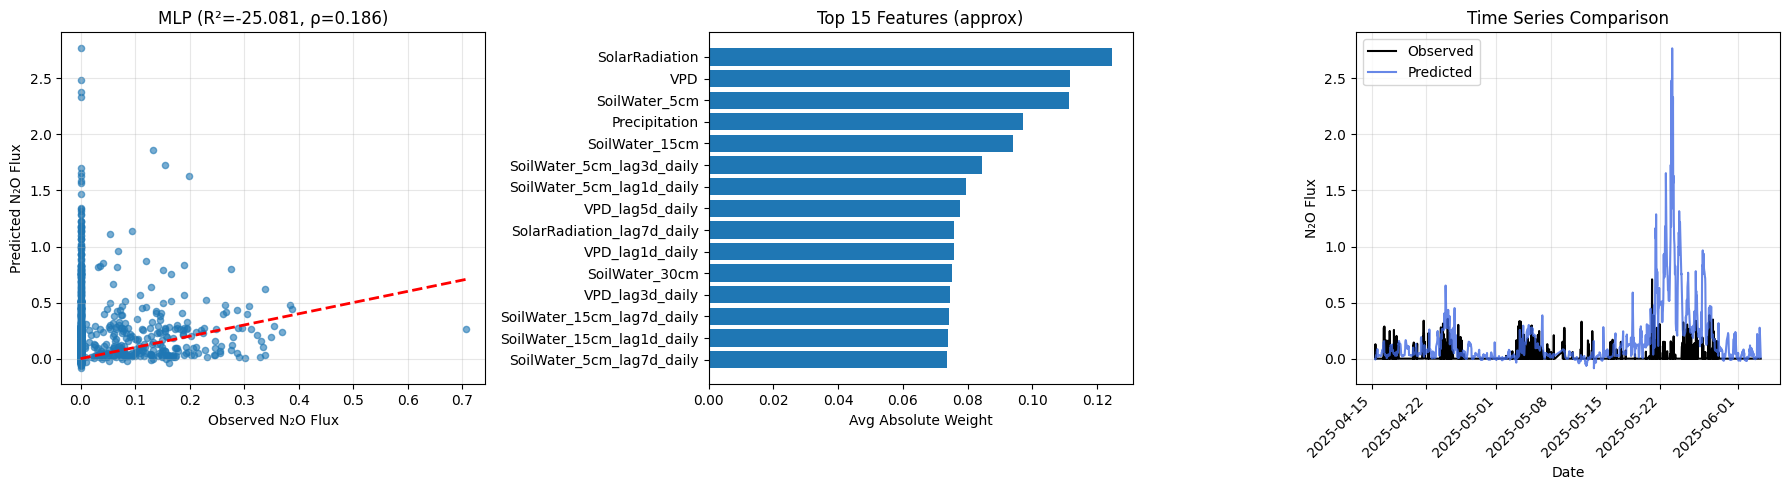


--- HOURLY | target=N2O_Flux_ln | predictors=AUGMENTED ---
Train period: 2023-11-07 15:45:00 → 2025-01-30 12:15:00
Test  period: 2025-01-30 12:45:00 → 2025-06-05 00:45:00

Training MLP...
Training stopped at iteration: 112

Model evaluation:
  R² (linear scale): -34.387
  Spearman ρ:        0.189


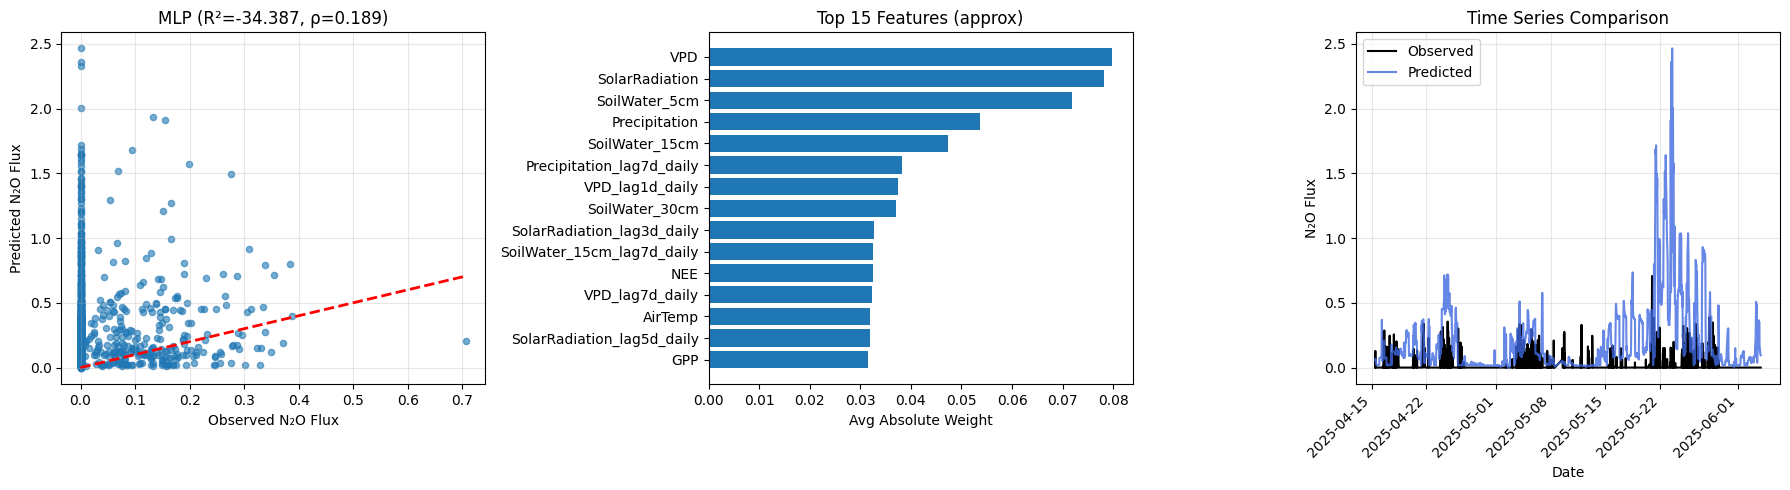


--- DAILY | target=N2O_Flux_ln | predictors=BASE ---
Train period: 2023-11-07 00:00:00 → 2025-02-16 00:00:00
Test  period: 2025-02-17 00:00:00 → 2025-06-04 00:00:00

Training MLP...
Training stopped at iteration: 164

Model evaluation:
  R² (linear scale): -80.506
  Spearman ρ:        0.242


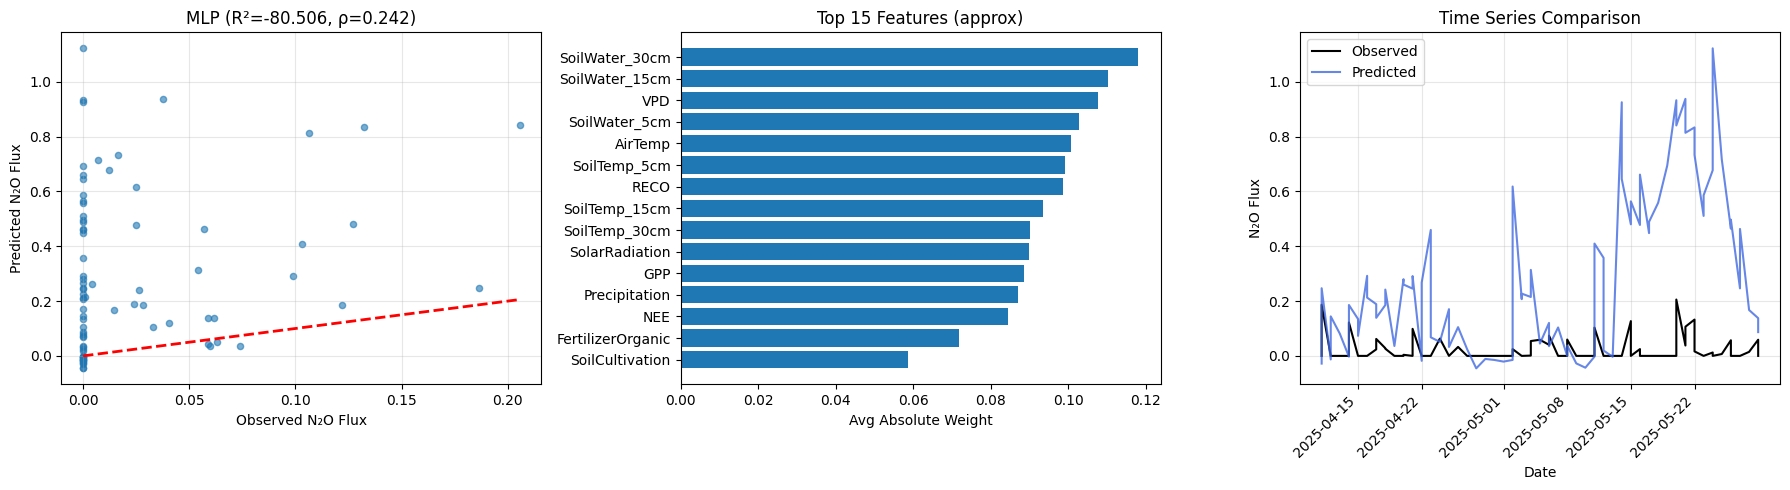


--- DAILY | target=N2O_Flux_ln | predictors=LAG ---
Train period: 2023-11-07 00:00:00 → 2025-02-03 00:00:00
Test  period: 2025-02-03 00:00:00 → 2025-06-04 00:00:00

Training MLP...
Training stopped at iteration: 97

Model evaluation:
  R² (linear scale): -77.693
  Spearman ρ:        0.426


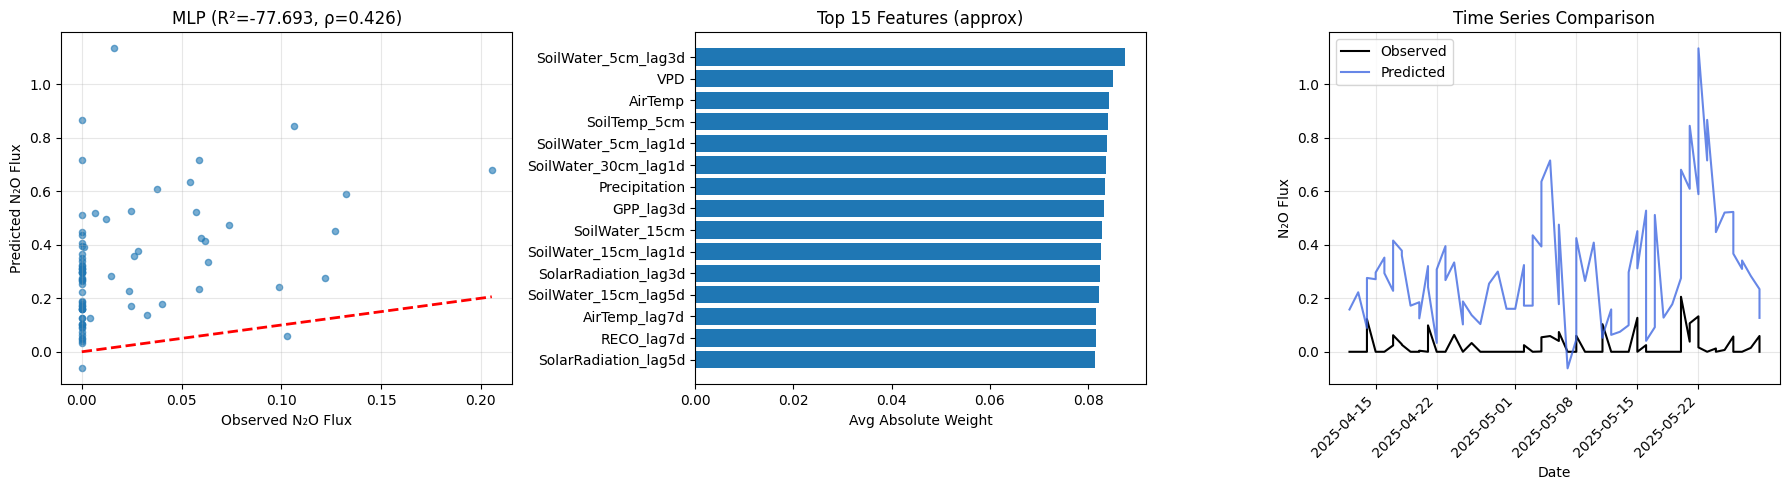


--- DAILY | target=N2O_Flux_ln | predictors=AUGMENTED ---
Train period: 2023-11-07 00:00:00 → 2025-02-03 00:00:00
Test  period: 2025-02-03 00:00:00 → 2025-06-04 00:00:00

Training MLP...
Training stopped at iteration: 62

Model evaluation:
  R² (linear scale): -37.763
  Spearman ρ:        0.240


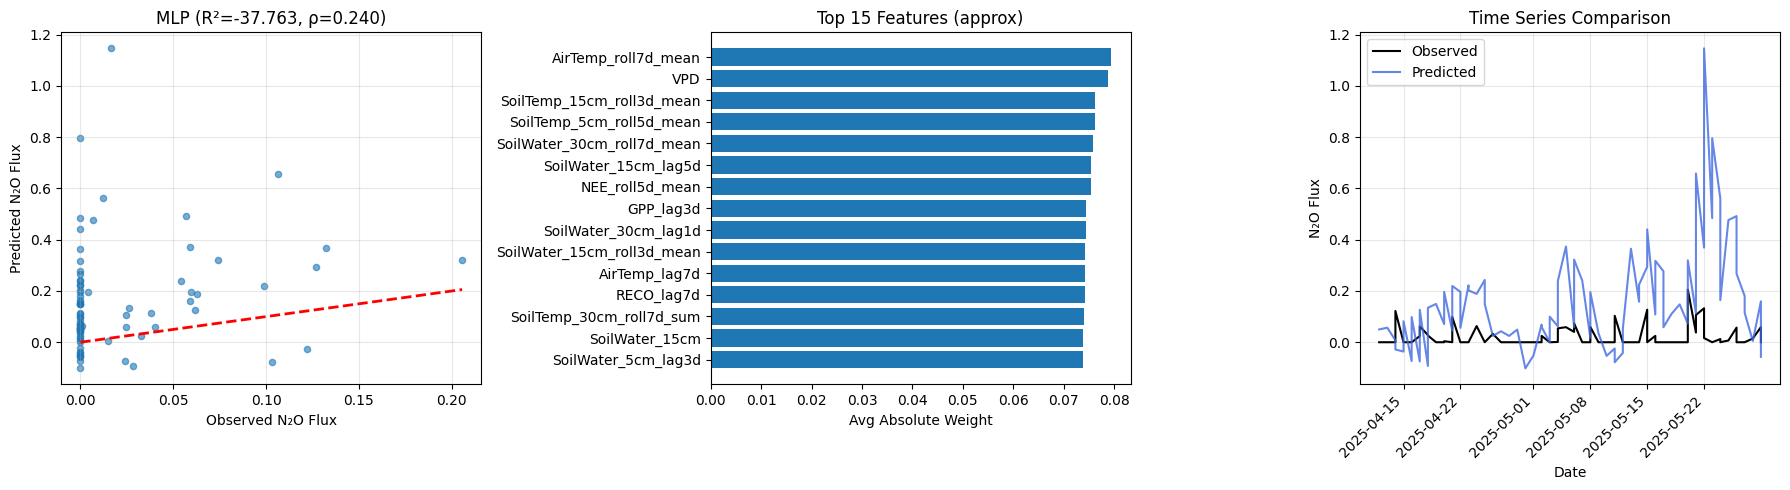


COMPREHENSIVE COMPARISON OF ALL EXPERIMENTS:
Temporal     Predictors   R²       Spearman ρ  
--------------------------------------------------------------------------------
Hourly       Base         -29.489        0.030
Hourly       Lag          -25.081        0.186
Hourly       Augmented    -34.387        0.189
Daily        Base         -80.506        0.242
Daily        Lag          -77.693        0.426
Daily        Augmented    -37.763        0.240

IMPROVEMENT FROM BASE TO LAG:
Hourly: R² +  4.408, ρ +  0.156
Daily:  R² +  2.813, ρ +  0.183

IMPROVEMENT FROM LAG TO AUGMENTED:
Hourly: R² + -9.306, ρ +  0.003
Daily:  R² + 39.931, ρ + -0.186


In [43]:
# ============================================================================
# TANIKON
# ============================================================================

print("="*80)
print("EXPERIMENT 3: Tanikon 2023-2025")
print("="*80)

# Define base and lag predictors
base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
]

hourly_lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilWater_30cm_lag1d_daily", "SoilWater_30cm_lag3d_daily", "SoilWater_30cm_lag5d_daily", "SoilWater_30cm_lag7d_daily",
    "SoilTemp_5cm_lag1d_daily", "SoilTemp_5cm_lag3d_daily", "SoilTemp_5cm_lag5d_daily", "SoilTemp_5cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "SoilTemp_30cm_lag1d_daily", "SoilTemp_30cm_lag3d_daily", "SoilTemp_30cm_lag5d_daily", "SoilTemp_30cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",

    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation"
]

hourly_augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilWater_30cm_lag1d_daily", "SoilWater_30cm_lag3d_daily", "SoilWater_30cm_lag5d_daily", "SoilWater_30cm_lag7d_daily",
    "SoilTemp_5cm_lag1d_daily", "SoilTemp_5cm_lag3d_daily", "SoilTemp_5cm_lag5d_daily", "SoilTemp_5cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "SoilTemp_30cm_lag1d_daily", "SoilTemp_30cm_lag3d_daily", "SoilTemp_30cm_lag5d_daily", "SoilTemp_30cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # Management events and days since
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation"
]

daily_lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",

    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation"
]

daily_augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # Management events and days since
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation"
]

# Store results for comparison
all_results = []

# ============================================================================
# HOURLY DATA - BASE PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=BASE ---")
print("="*80)

results_hourly_base = train_mlp_timeseries(
    df=tanikon_lag,
    predictors=base_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Base", results_hourly_base['r2'], results_hourly_base['spearman_rho']))


# ============================================================================
# HOURLY DATA - LAG PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=LAG ---")
print("="*80)

results_hourly_lag = train_mlp_timeseries(
    df=tanikon_lag,
    predictors=hourly_lag_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Lag", results_hourly_lag['r2'], results_hourly_lag['spearman_rho']))


# ============================================================================
# HOURLY DATA - AUGMENTED PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=AUGMENTED ---")
print("="*80)

results_hourly_augmented = train_mlp_timeseries(
    df=tanikon_lag,
    predictors=hourly_augmented_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Augmented", results_hourly_augmented['r2'], results_hourly_augmented['spearman_rho']))

# ============================================================================
# DAILY DATA - BASE PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=BASE ---")
print("="*80)

results_daily_base = train_mlp_timeseries(
    df=tanikon_daily,
    predictors=base_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Base", results_daily_base['r2'], results_daily_base['spearman_rho']))

# ============================================================================
# DAILY DATA - LAG PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=LAG ---")
print("="*80)

results_daily_lag = train_mlp_timeseries(
    df=tanikon_daily,
    predictors=daily_lag_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Lag", results_daily_lag['r2'], results_daily_lag['spearman_rho']))


# ============================================================================
# DAILY DATA - AUGMENTED PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=AUGMENTED ---")
print("="*80)

results_daily_augmented = train_mlp_timeseries(
    df=tanikon_daily,
    predictors=daily_augmented_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Augmented", results_daily_augmented['r2'], results_daily_augmented['spearman_rho']))

# ============================================================================
# COMPREHENSIVE COMPARISON
# ============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON OF ALL EXPERIMENTS:")
print("="*80)
print(f"{'Temporal':<12} {'Predictors':<12} {'R²':<8} {'Spearman ρ':<12}")
print("-"*80)
for temp, pred, r2, rho in all_results:
    print(f"{temp:<12} {pred:<12} {r2:>6.3f}   {rho:>10.3f}")

print("\n" + "="*80)
print("IMPROVEMENT FROM BASE TO LAG:")
print("="*80)
print(f"Hourly: R² + {(results_hourly_lag['r2'] - results_hourly_base['r2']):>6.3f}, ρ + {(results_hourly_lag['spearman_rho'] - results_hourly_base['spearman_rho']):>6.3f}")
print(f"Daily:  R² + {(results_daily_lag['r2'] - results_daily_base['r2']):>6.3f}, ρ + {(results_daily_lag['spearman_rho'] - results_daily_base['spearman_rho']):>6.3f}")

print("\n" + "="*80)
print("IMPROVEMENT FROM LAG TO AUGMENTED:")
print("="*80)
print(f"Hourly: R² + {(results_hourly_augmented['r2'] - results_hourly_lag['r2']):>6.3f}, ρ + {(results_hourly_augmented['spearman_rho'] - results_hourly_lag['spearman_rho']):>6.3f}")
print(f"Daily:  R² + {(results_daily_augmented['r2'] - results_daily_lag['r2']):>6.3f}, ρ + {(results_daily_augmented['spearman_rho'] - results_daily_lag['spearman_rho']):>6.3f}")

# Experiment 4: Oensingen 2021-23

In [48]:
# FIX TIMESTAMP
oensingen_2_lag['Timestamp'] = pd.to_datetime(oensingen_2_lag['Timestamp'])
oensingen_2_lag = oensingen_2_lag.set_index('Timestamp').sort_index()

oensingen_2_daily['Date'] = pd.to_datetime(oensingen_2_daily['Date'])
oensingen_2_daily = oensingen_2_daily.set_index('Date').sort_index()

EXPERIMENT 4: Oensingen 2021-2023

--- HOURLY | target=N2O_Flux_ln | predictors=BASE ---
Train period: 2022-08-30 11:45:00 → 2023-08-15 09:15:00
Test  period: 2023-08-15 14:45:00 → 2023-10-05 12:15:00

Training MLP...
Training stopped at iteration: 140

Model evaluation:
  R² (linear scale): -0.166
  Spearman ρ:        0.140


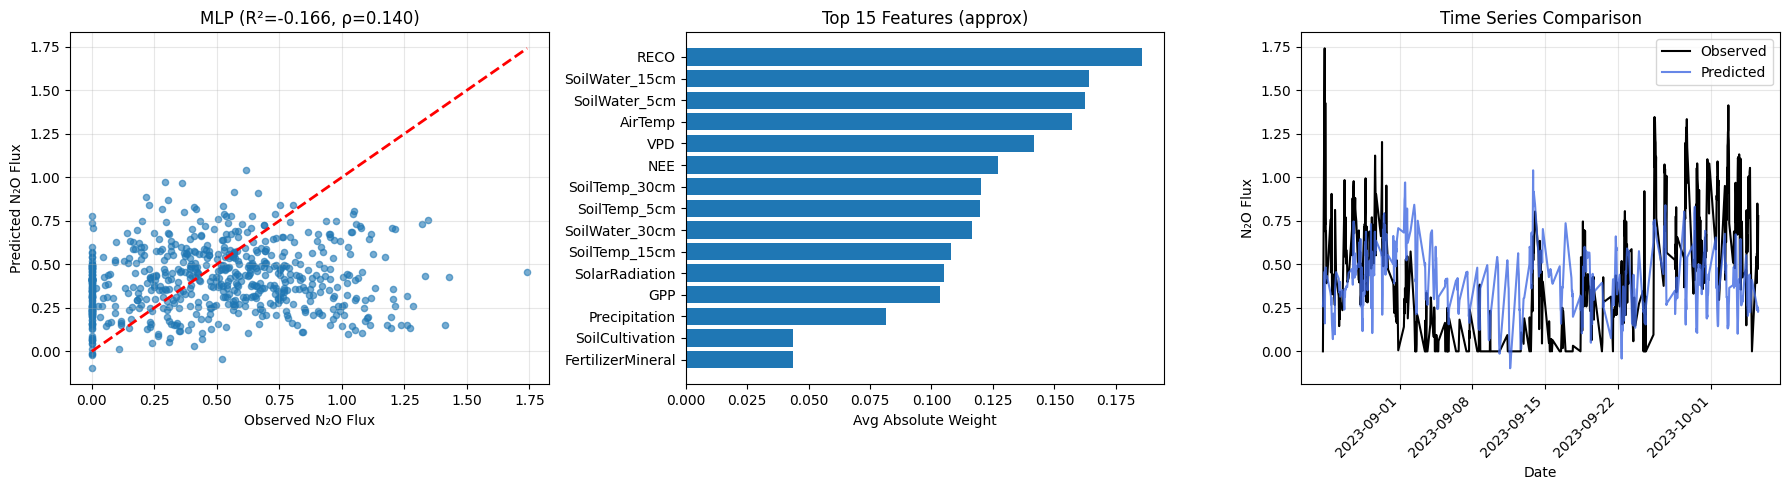


--- HOURLY | target=N2O_Flux_ln | predictors=LAG ---
Train period: 2022-08-30 11:45:00 → 2023-08-15 09:15:00
Test  period: 2023-08-15 14:45:00 → 2023-10-05 12:15:00

Training MLP...
Training stopped at iteration: 112

Model evaluation:
  R² (linear scale): -0.264
  Spearman ρ:        0.556


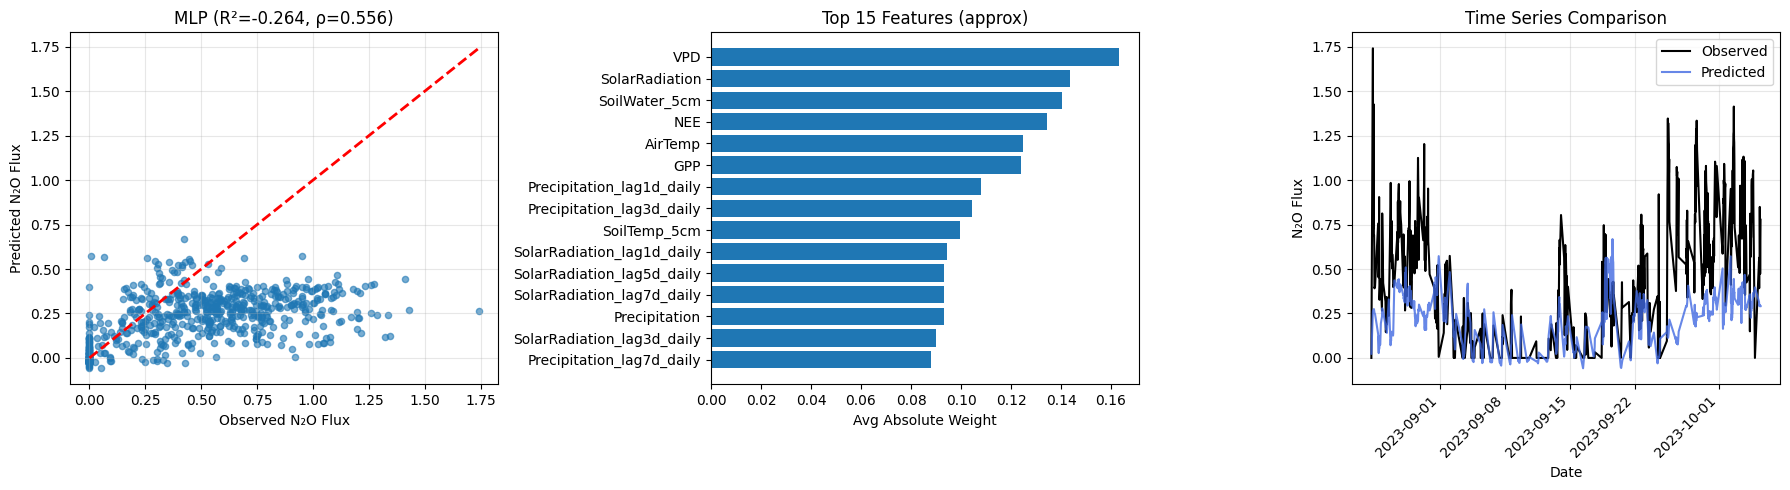


--- HOURLY | target=N2O_Flux_ln | predictors=AUGMENTED ---
Train period: 2022-08-30 11:45:00 → 2023-08-15 09:15:00
Test  period: 2023-08-15 14:45:00 → 2023-10-05 12:15:00

Training MLP...
Training stopped at iteration: 113

Model evaluation:
  R² (linear scale): -0.381
  Spearman ρ:        0.526


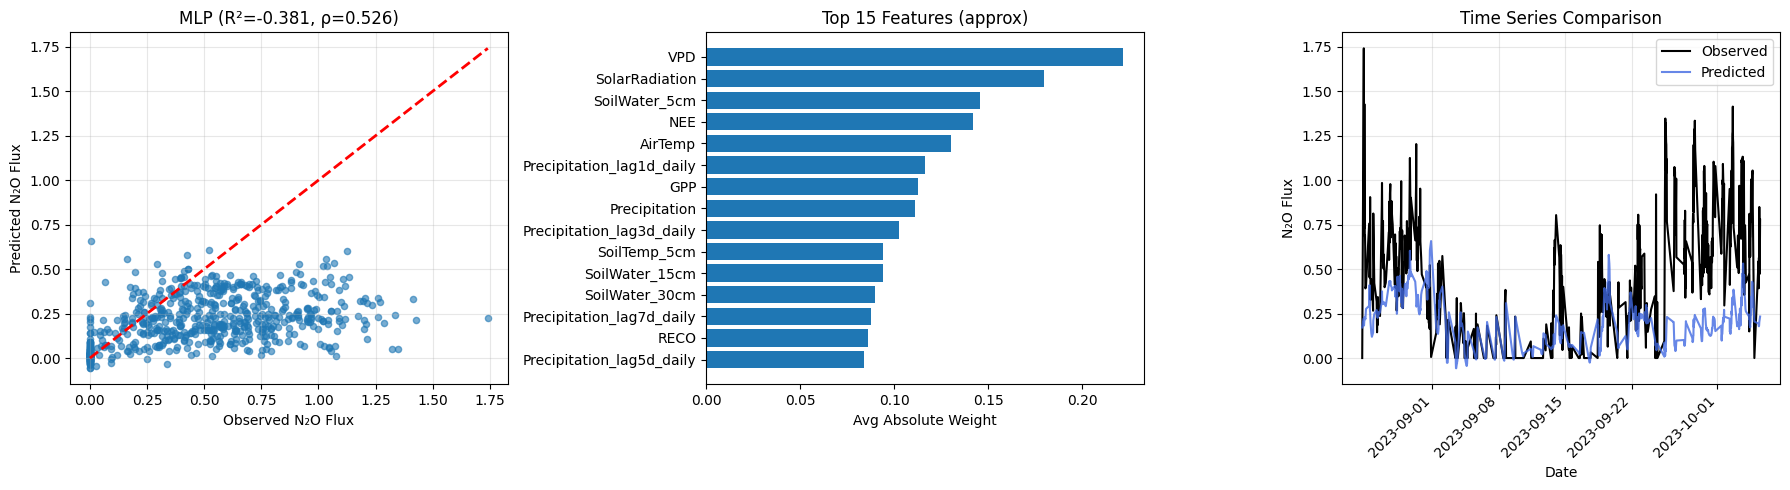


--- DAILY | target=N2O_Flux_ln | predictors=BASE ---
Train period: 2022-08-30 00:00:00 → 2023-08-28 00:00:00
Test  period: 2023-08-29 00:00:00 → 2023-10-05 00:00:00

Training MLP...
Training stopped at iteration: 44

Model evaluation:
  R² (linear scale): 0.590
  Spearman ρ:        0.846


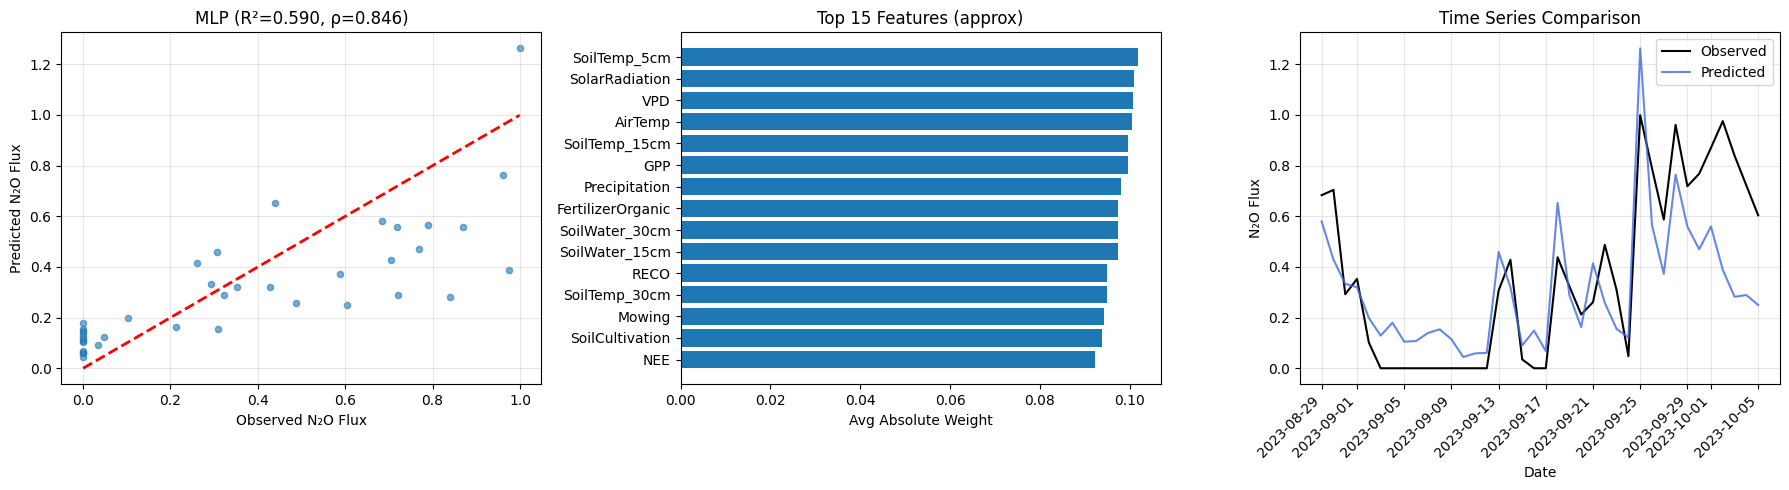


--- DAILY | target=N2O_Flux_ln | predictors=LAG ---
Train period: 2022-08-30 00:00:00 → 2023-08-22 00:00:00
Test  period: 2023-08-23 00:00:00 → 2023-10-05 00:00:00

Training MLP...
Training stopped at iteration: 59

Model evaluation:
  R² (linear scale): -0.453
  Spearman ρ:        0.483


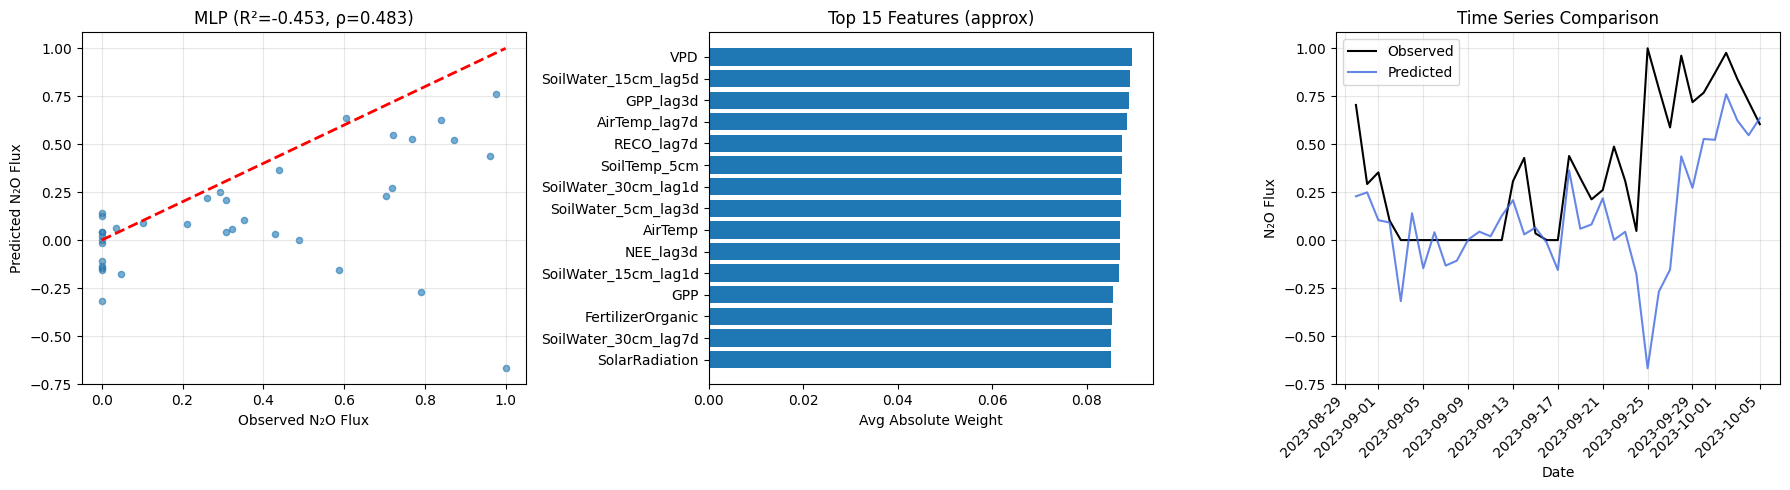


--- DAILY | target=N2O_Flux_ln | predictors=AUGMENTED ---
Train period: 2022-08-30 00:00:00 → 2023-08-22 00:00:00
Test  period: 2023-08-23 00:00:00 → 2023-10-05 00:00:00

Training MLP...
Training stopped at iteration: 78

Model evaluation:
  R² (linear scale): 0.142
  Spearman ρ:        0.748


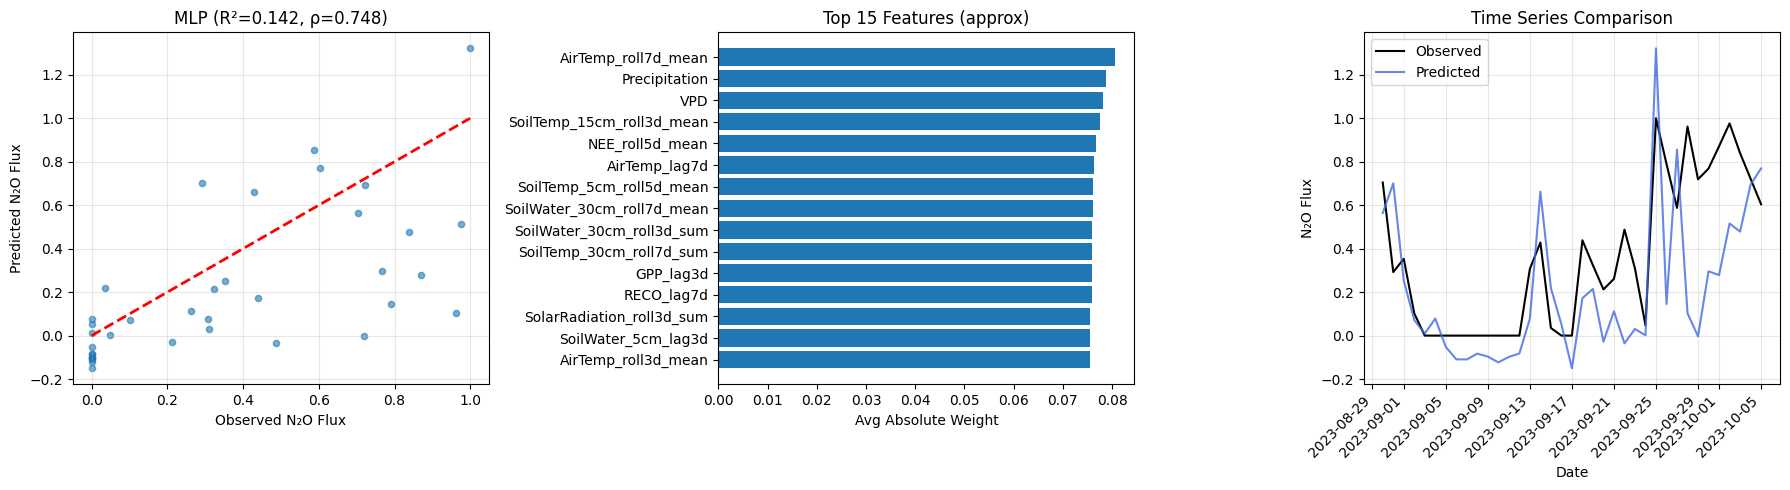


COMPREHENSIVE COMPARISON OF ALL EXPERIMENTS:
Temporal     Predictors   R²       Spearman ρ  
--------------------------------------------------------------------------------
Hourly       Base         -0.166        0.140
Hourly       Lag          -0.264        0.556
Hourly       Augmented    -0.381        0.526
Daily        Base          0.590        0.846
Daily        Lag          -0.453        0.483
Daily        Augmented     0.142        0.748

IMPROVEMENT FROM BASE TO LAG:
Hourly: R² + -0.098, ρ +  0.416
Daily:  R² + -1.043, ρ + -0.362

IMPROVEMENT FROM LAG TO AUGMENTED:
Hourly: R² + -0.117, ρ + -0.030
Daily:  R² +  0.595, ρ +  0.264


In [45]:
# ============================================================================
# OENSINGEN 2
# ============================================================================

print("="*80)
print("EXPERIMENT 4: Oensingen 2021-2023")
print("="*80)

# Define base and lag predictors
base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
]

hourly_lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilWater_30cm_lag1d_daily", "SoilWater_30cm_lag3d_daily", "SoilWater_30cm_lag5d_daily", "SoilWater_30cm_lag7d_daily",
    "SoilTemp_5cm_lag1d_daily", "SoilTemp_5cm_lag3d_daily", "SoilTemp_5cm_lag5d_daily", "SoilTemp_5cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "SoilTemp_30cm_lag1d_daily", "SoilTemp_30cm_lag3d_daily", "SoilTemp_30cm_lag5d_daily", "SoilTemp_30cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",

    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation"
]

hourly_augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilWater_30cm_lag1d_daily", "SoilWater_30cm_lag3d_daily", "SoilWater_30cm_lag5d_daily", "SoilWater_30cm_lag7d_daily",
    "SoilTemp_5cm_lag1d_daily", "SoilTemp_5cm_lag3d_daily", "SoilTemp_5cm_lag5d_daily", "SoilTemp_5cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "SoilTemp_30cm_lag1d_daily", "SoilTemp_30cm_lag3d_daily", "SoilTemp_30cm_lag5d_daily", "SoilTemp_30cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # Management events and days since
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation"
]

daily_lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",

    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation"
]

daily_augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # Management events and days since
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation"
]

# Store results for comparison
all_results = []

# ============================================================================
# HOURLY DATA - BASE PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=BASE ---")
print("="*80)

results_hourly_base = train_mlp_timeseries(
    df=oensingen_2_lag,
    predictors=base_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Base", results_hourly_base['r2'], results_hourly_base['spearman_rho']))


# ============================================================================
# HOURLY DATA - LAG PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=LAG ---")
print("="*80)

results_hourly_lag = train_mlp_timeseries(
    df=oensingen_2_lag,
    predictors=hourly_lag_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Lag", results_hourly_lag['r2'], results_hourly_lag['spearman_rho']))


# ============================================================================
# HOURLY DATA - AUGMENTED PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=AUGMENTED ---")
print("="*80)

results_hourly_augmented = train_mlp_timeseries(
    df=oensingen_2_lag,
    predictors=hourly_augmented_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Augmented", results_hourly_augmented['r2'], results_hourly_augmented['spearman_rho']))

# ============================================================================
# DAILY DATA - BASE PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=BASE ---")
print("="*80)

results_daily_base = train_mlp_timeseries(
    df=oensingen_2_daily,
    predictors=base_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Base", results_daily_base['r2'], results_daily_base['spearman_rho']))

# ============================================================================
# DAILY DATA - LAG PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=LAG ---")
print("="*80)

results_daily_lag = train_mlp_timeseries(
    df=oensingen_2_daily,
    predictors=daily_lag_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Lag", results_daily_lag['r2'], results_daily_lag['spearman_rho']))


# ============================================================================
# DAILY DATA - AUGMENTED PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=AUGMENTED ---")
print("="*80)

results_daily_augmented = train_mlp_timeseries(
    df=oensingen_2_daily,
    predictors=daily_augmented_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Augmented", results_daily_augmented['r2'], results_daily_augmented['spearman_rho']))

# ============================================================================
# COMPREHENSIVE COMPARISON
# ============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON OF ALL EXPERIMENTS:")
print("="*80)
print(f"{'Temporal':<12} {'Predictors':<12} {'R²':<8} {'Spearman ρ':<12}")
print("-"*80)
for temp, pred, r2, rho in all_results:
    print(f"{temp:<12} {pred:<12} {r2:>6.3f}   {rho:>10.3f}")

print("\n" + "="*80)
print("IMPROVEMENT FROM BASE TO LAG:")
print("="*80)
print(f"Hourly: R² + {(results_hourly_lag['r2'] - results_hourly_base['r2']):>6.3f}, ρ + {(results_hourly_lag['spearman_rho'] - results_hourly_base['spearman_rho']):>6.3f}")
print(f"Daily:  R² + {(results_daily_lag['r2'] - results_daily_base['r2']):>6.3f}, ρ + {(results_daily_lag['spearman_rho'] - results_daily_base['spearman_rho']):>6.3f}")

print("\n" + "="*80)
print("IMPROVEMENT FROM LAG TO AUGMENTED:")
print("="*80)
print(f"Hourly: R² + {(results_hourly_augmented['r2'] - results_hourly_lag['r2']):>6.3f}, ρ + {(results_hourly_augmented['spearman_rho'] - results_hourly_lag['spearman_rho']):>6.3f}")
print(f"Daily:  R² + {(results_daily_augmented['r2'] - results_daily_lag['r2']):>6.3f}, ρ + {(results_daily_augmented['spearman_rho'] - results_daily_lag['spearman_rho']):>6.3f}")

# Experiment 5: Aeschi

In [49]:
# FIX TIMESTAMP
aeschi_lag['Timestamp'] = pd.to_datetime(aeschi_lag['Timestamp'])
aeschi_lag = aeschi_lag.set_index('Timestamp').sort_index()

aeschi_daily['Date'] = pd.to_datetime(aeschi_daily['Date'])
aeschi_daily = aeschi_daily.set_index('Date').sort_index()

EXPERIMENT 5: Aeschi 2019-2020

--- HOURLY | target=N2O_Flux_ln | predictors=BASE ---
Train period: 2019-05-10 00:15:00 → 2020-09-05 12:15:00
Test  period: 2020-09-05 13:45:00 → 2020-11-02 23:45:00

Training MLP...
Training stopped at iteration: 100

Model evaluation:
  R² (linear scale): -2.045
  Spearman ρ:        0.117


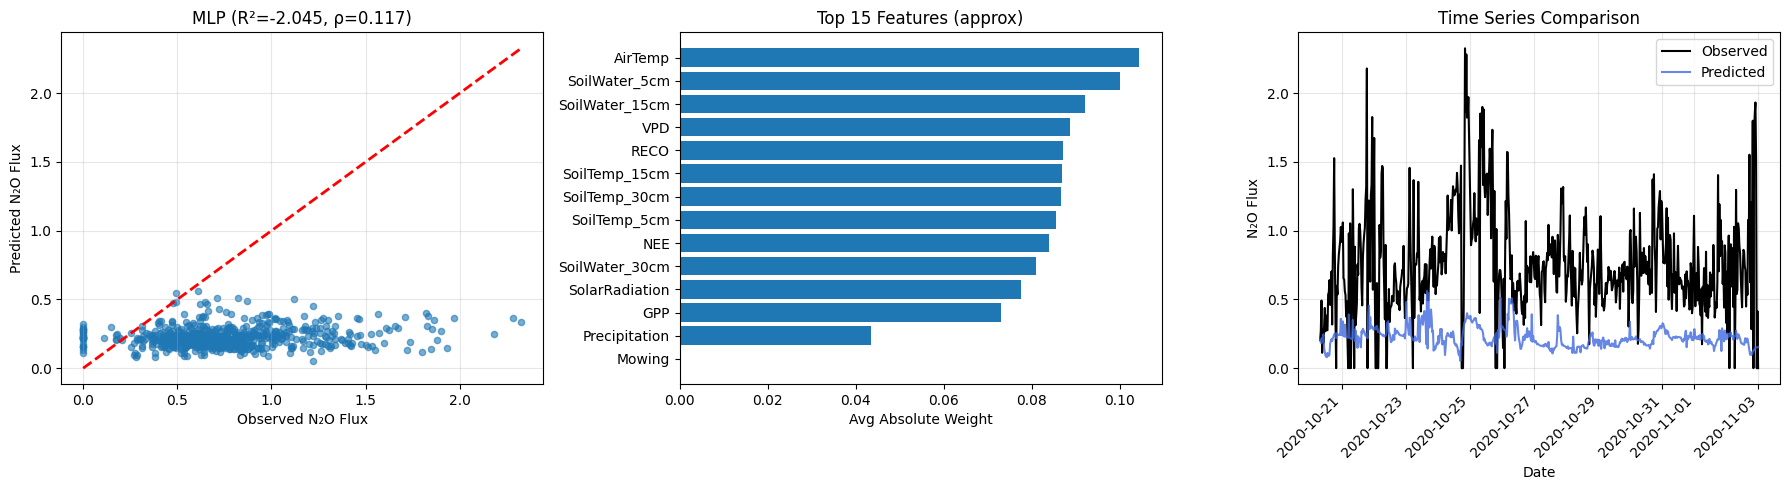


--- HOURLY | target=N2O_Flux_ln | predictors=LAG ---
Train period: 2019-05-10 00:15:00 → 2020-08-18 21:15:00
Test  period: 2020-08-18 21:45:00 → 2020-11-02 23:45:00

Training MLP...
Training stopped at iteration: 105

Model evaluation:
  R² (linear scale): -1.002
  Spearman ρ:        0.214


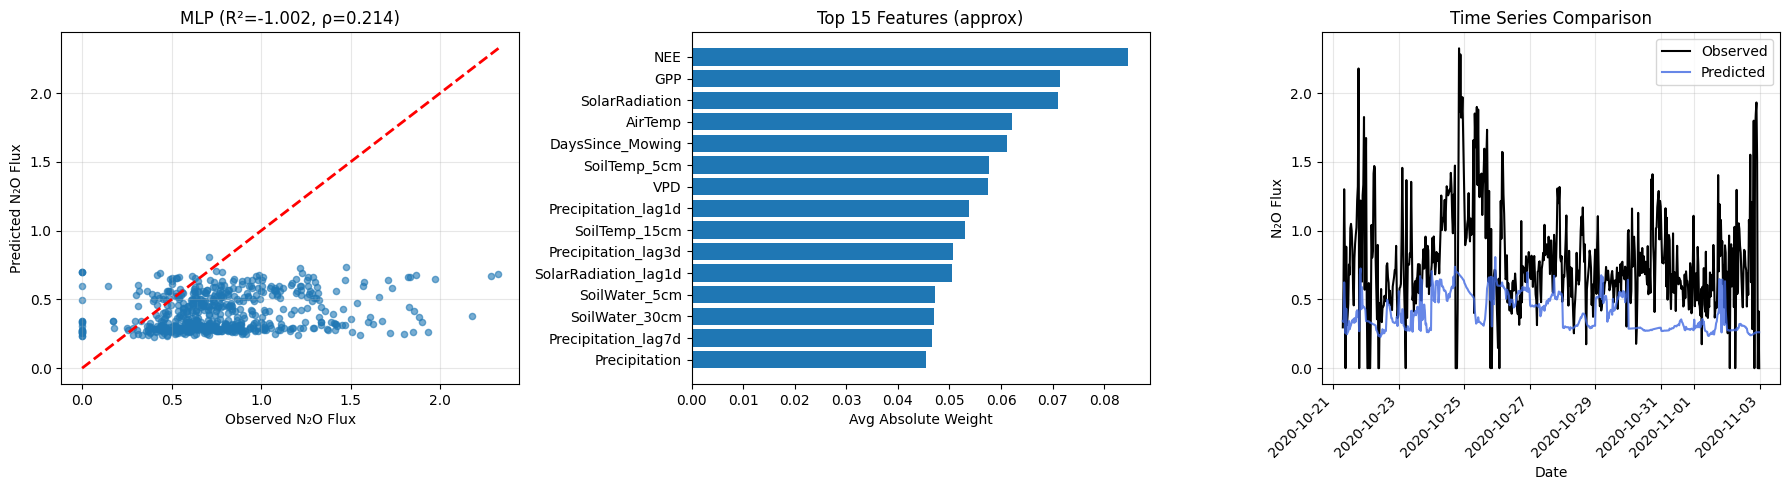


--- HOURLY | target=N2O_Flux_ln | predictors=AUGMENTED ---
Train period: 2019-05-10 00:15:00 → 2020-08-18 21:15:00
Test  period: 2020-08-18 21:45:00 → 2020-11-02 23:45:00

Training MLP...
Training stopped at iteration: 77

Model evaluation:
  R² (linear scale): -0.524
  Spearman ρ:        0.167


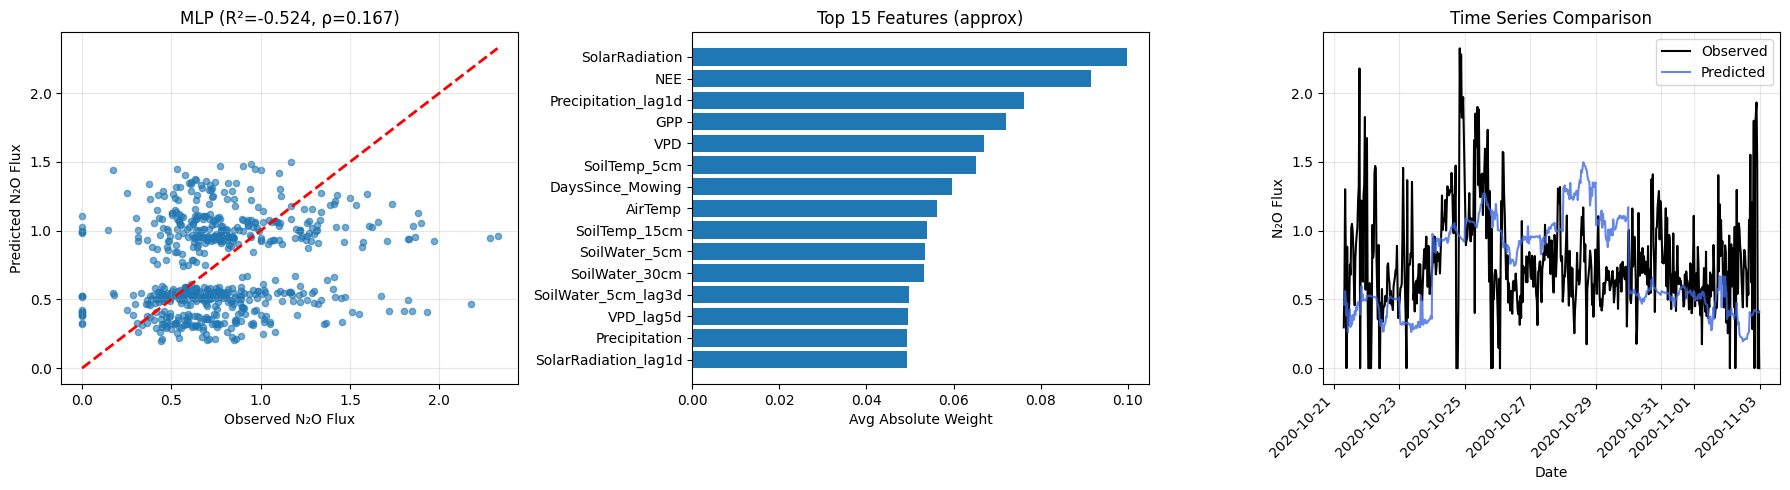


--- DAILY | target=N2O_Flux_ln | predictors=BASE ---
Train period: 2019-05-10 00:00:00 → 2020-09-29 00:00:00
Test  period: 2020-09-30 00:00:00 → 2020-11-02 00:00:00

Training MLP...
Training stopped at iteration: 77

Model evaluation:
  R² (linear scale): -0.919
  Spearman ρ:        -0.576


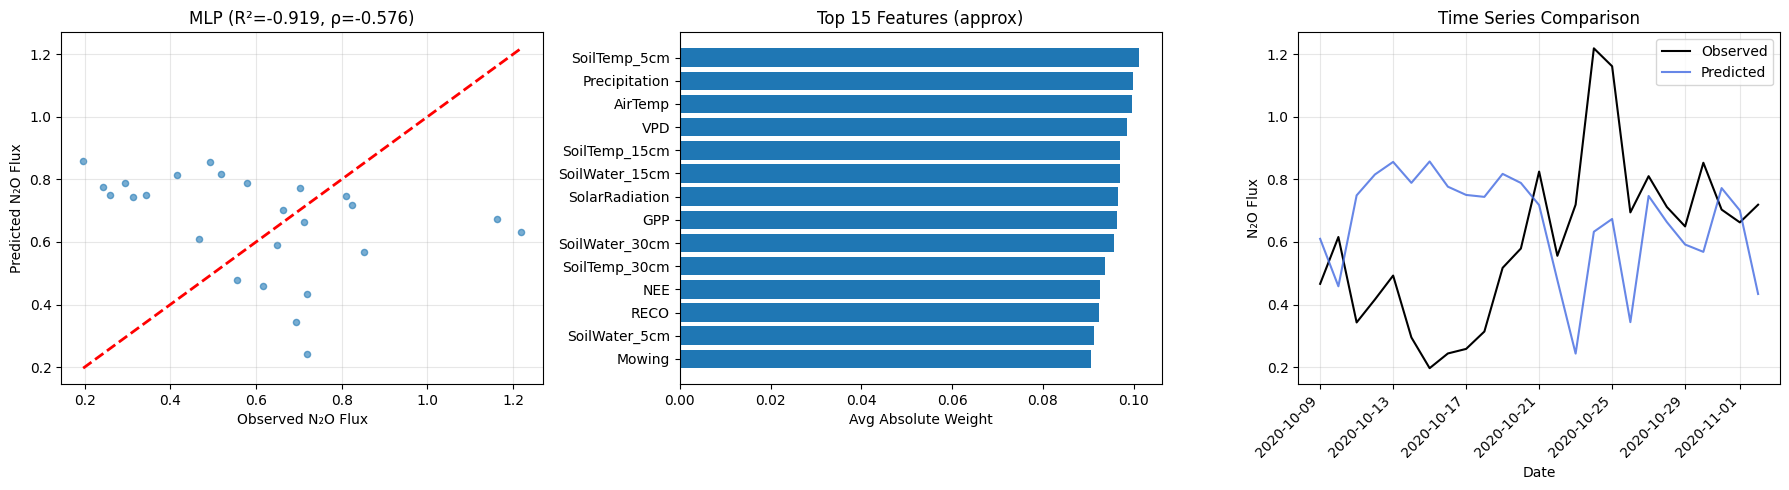


--- DAILY | target=N2O_Flux_ln | predictors=LAG ---
Train period: 2019-05-10 00:00:00 → 2020-09-20 00:00:00
Test  period: 2020-09-21 00:00:00 → 2020-11-02 00:00:00

Training MLP...
Training stopped at iteration: 145

Model evaluation:
  R² (linear scale): -1.313
  Spearman ρ:        -0.062


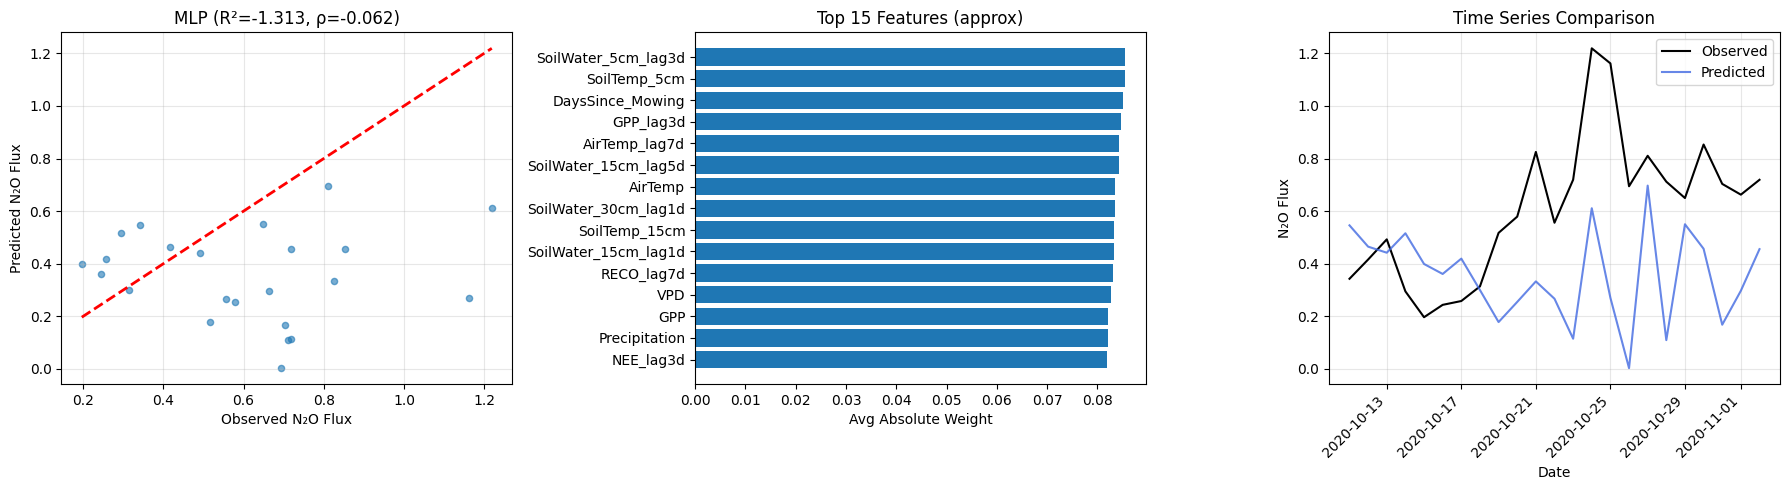


--- DAILY | target=N2O_Flux_ln | predictors=AUGMENTED ---
Train period: 2019-05-10 00:00:00 → 2020-09-20 00:00:00
Test  period: 2020-09-21 00:00:00 → 2020-11-02 00:00:00

Training MLP...
Training stopped at iteration: 51

Model evaluation:
  R² (linear scale): 0.021
  Spearman ρ:        0.549


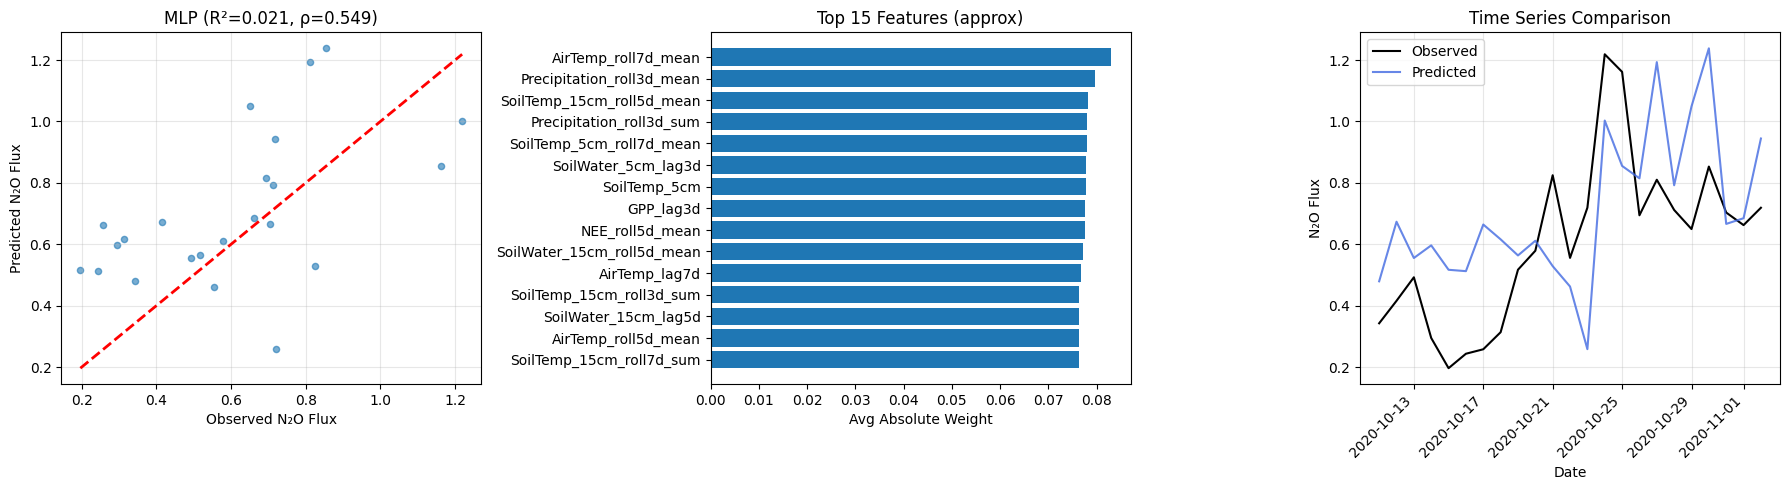


COMPREHENSIVE COMPARISON OF ALL EXPERIMENTS:
Temporal     Predictors   R²       Spearman ρ  
--------------------------------------------------------------------------------
Hourly       Base         -2.045        0.117
Hourly       Lag          -1.002        0.214
Hourly       Augmented    -0.524        0.167
Daily        Base         -0.919       -0.576
Daily        Lag          -1.313       -0.062
Daily        Augmented     0.021        0.549

IMPROVEMENT FROM BASE TO LAG:
Hourly: R² +  1.043, ρ +  0.098
Daily:  R² + -0.395, ρ +  0.514

IMPROVEMENT FROM LAG TO AUGMENTED:
Hourly: R² +  0.477, ρ + -0.047
Daily:  R² +  1.334, ρ +  0.612


In [50]:
# ============================================================================
# AESCHI
# ============================================================================

print("="*80)
print("EXPERIMENT 5: Aeschi 2019-2020")
print("="*80)

# Define base and lag predictors
base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    "Mowing",
]

lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",

    # --- Management variables ---
    "Mowing", "DaysSince_Mowing"
]

augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # --- Management variables ---
    "Mowing", "DaysSince_Mowing"
]

# Store results for comparison
all_results = []

# ============================================================================
# HOURLY DATA - BASE PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=BASE ---")
print("="*80)

results_hourly_base = train_mlp_timeseries(
    df=aeschi_lag,
    predictors=base_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Base", results_hourly_base['r2'], results_hourly_base['spearman_rho']))


# ============================================================================
# HOURLY DATA - LAG PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=LAG ---")
print("="*80)

results_hourly_lag = train_mlp_timeseries(
    df=aeschi_lag,
    predictors=lag_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Lag", results_hourly_lag['r2'], results_hourly_lag['spearman_rho']))


# ============================================================================
# HOURLY DATA - AUGMENTED PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=AUGMENTED ---")
print("="*80)

results_hourly_augmented = train_mlp_timeseries(
    df=aeschi_lag,
    predictors=augmented_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Augmented", results_hourly_augmented['r2'], results_hourly_augmented['spearman_rho']))

# ============================================================================
# DAILY DATA - BASE PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=BASE ---")
print("="*80)

results_daily_base = train_mlp_timeseries(
    df=aeschi_daily,
    predictors=base_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Base", results_daily_base['r2'], results_daily_base['spearman_rho']))

# ============================================================================
# DAILY DATA - LAG PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=LAG ---")
print("="*80)

results_daily_lag = train_mlp_timeseries(
    df=aeschi_daily,
    predictors=lag_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Lag", results_daily_lag['r2'], results_daily_lag['spearman_rho']))


# ============================================================================
# DAILY DATA - AUGMENTED PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=AUGMENTED ---")
print("="*80)

results_daily_augmented = train_mlp_timeseries(
    df=aeschi_daily,
    predictors=augmented_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Augmented", results_daily_augmented['r2'], results_daily_augmented['spearman_rho']))

# ============================================================================
# COMPREHENSIVE COMPARISON
# ============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON OF ALL EXPERIMENTS:")
print("="*80)
print(f"{'Temporal':<12} {'Predictors':<12} {'R²':<8} {'Spearman ρ':<12}")
print("-"*80)
for temp, pred, r2, rho in all_results:
    print(f"{temp:<12} {pred:<12} {r2:>6.3f}   {rho:>10.3f}")

print("\n" + "="*80)
print("IMPROVEMENT FROM BASE TO LAG:")
print("="*80)
print(f"Hourly: R² + {(results_hourly_lag['r2'] - results_hourly_base['r2']):>6.3f}, ρ + {(results_hourly_lag['spearman_rho'] - results_hourly_base['spearman_rho']):>6.3f}")
print(f"Daily:  R² + {(results_daily_lag['r2'] - results_daily_base['r2']):>6.3f}, ρ + {(results_daily_lag['spearman_rho'] - results_daily_base['spearman_rho']):>6.3f}")

print("\n" + "="*80)
print("IMPROVEMENT FROM LAG TO AUGMENTED:")
print("="*80)
print(f"Hourly: R² + {(results_hourly_augmented['r2'] - results_hourly_lag['r2']):>6.3f}, ρ + {(results_hourly_augmented['spearman_rho'] - results_hourly_lag['spearman_rho']):>6.3f}")
print(f"Daily:  R² + {(results_daily_augmented['r2'] - results_daily_lag['r2']):>6.3f}, ρ + {(results_daily_augmented['spearman_rho'] - results_daily_lag['spearman_rho']):>6.3f}")

# Experiment 6: Oensingen 2018-20

In [51]:
# FIX TIMESTAMP
oensingen_1_lag['Timestamp'] = pd.to_datetime(oensingen_1_lag['Timestamp'])
oensingen_1_lag = oensingen_1_lag.set_index('Timestamp').sort_index()

oensingen_1_daily['Date'] = pd.to_datetime(oensingen_1_daily['Date'])
oensingen_1_daily = oensingen_1_daily.set_index('Date').sort_index()

EXPERIMENT 6: Oensingen 2018-2019

--- HOURLY | target=N2O_Flux_ln | predictors=BASE ---
Train period: 2018-07-12 07:45:00 → 2019-09-09 01:45:00
Test  period: 2019-09-09 02:15:00 → 2019-10-04 23:15:00

Training MLP...
Training stopped at iteration: 76

Model evaluation:
  R² (linear scale): 0.213
  Spearman ρ:        0.547


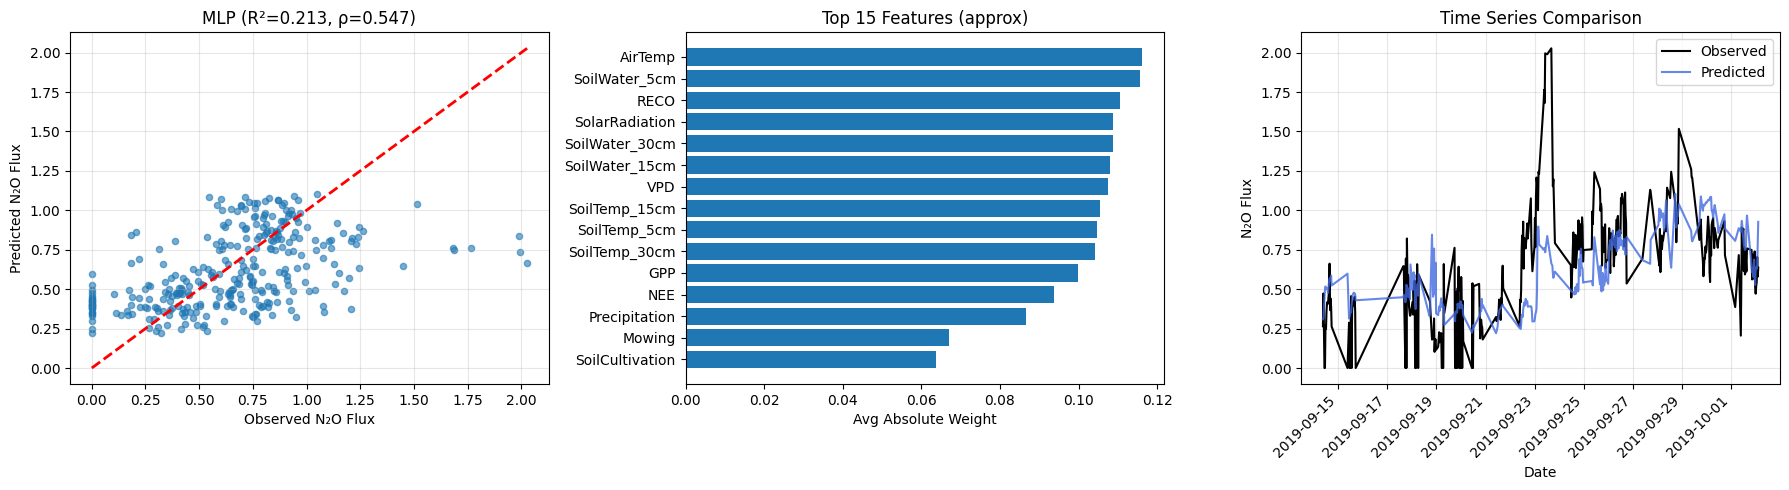


--- HOURLY | target=N2O_Flux_ln | predictors=LAG ---
Train period: 2018-07-12 07:45:00 → 2019-08-18 11:15:00
Test  period: 2019-08-18 11:45:00 → 2019-10-04 23:15:00

Training MLP...
Training stopped at iteration: 78

Model evaluation:
  R² (linear scale): -0.004
  Spearman ρ:        0.640


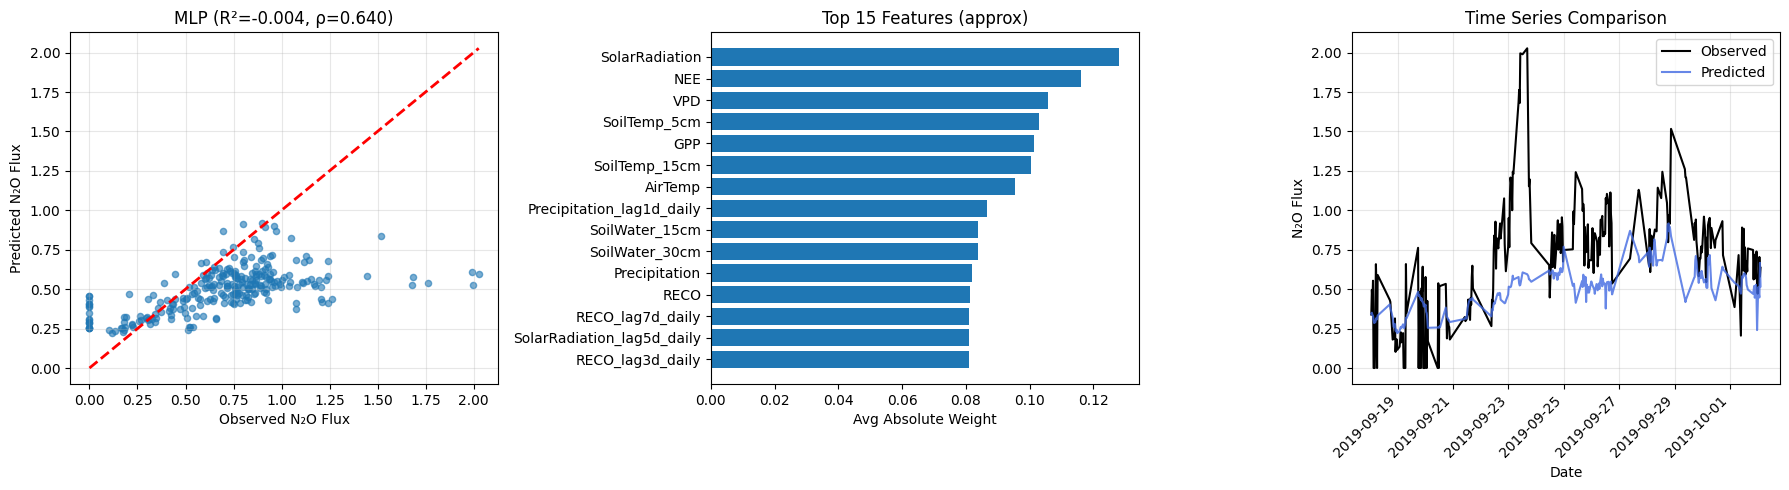


--- HOURLY | target=N2O_Flux_ln | predictors=AUGMENTED ---
Train period: 2018-07-12 07:45:00 → 2019-08-18 11:15:00
Test  period: 2019-08-18 11:45:00 → 2019-10-04 23:15:00

Training MLP...
Training stopped at iteration: 83

Model evaluation:
  R² (linear scale): 0.203
  Spearman ρ:        0.650


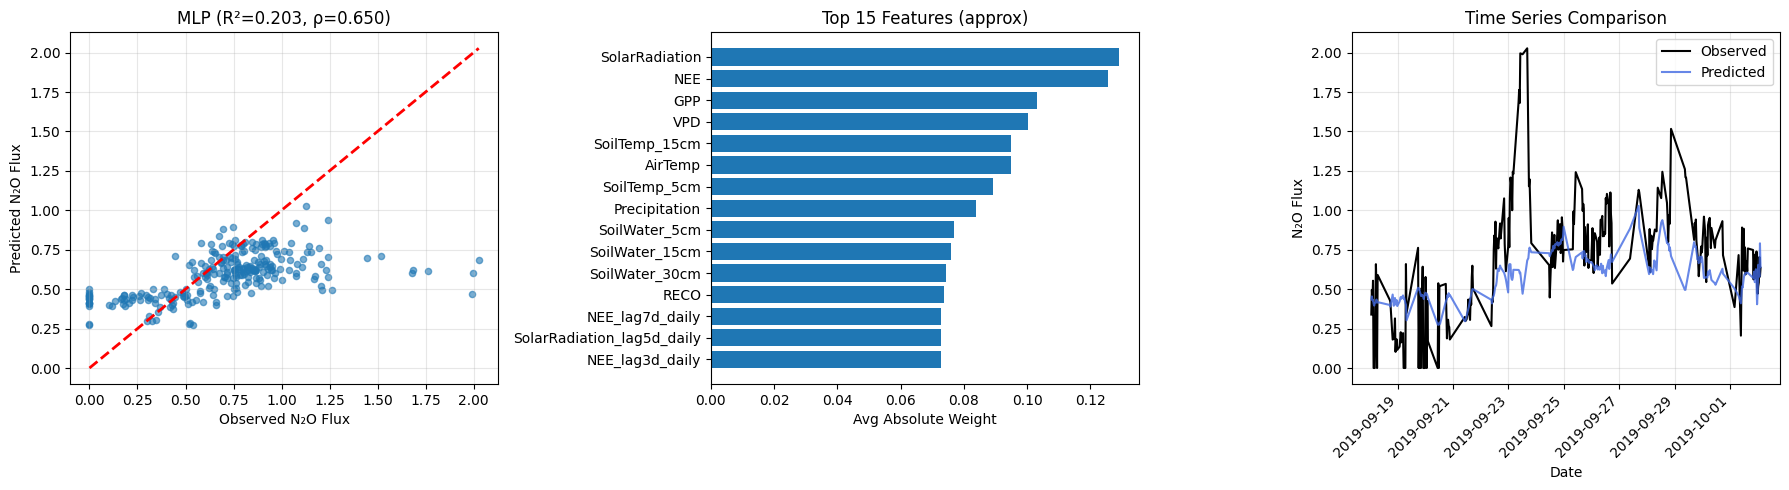


--- DAILY | target=N2O_Flux_ln | predictors=BASE ---
Train period: 2018-07-12 00:00:00 → 2019-09-12 00:00:00
Test  period: 2019-09-13 00:00:00 → 2019-10-04 00:00:00

Training MLP...
Training stopped at iteration: 55

Model evaluation:
  R² (linear scale): 0.012
  Spearman ρ:        0.576


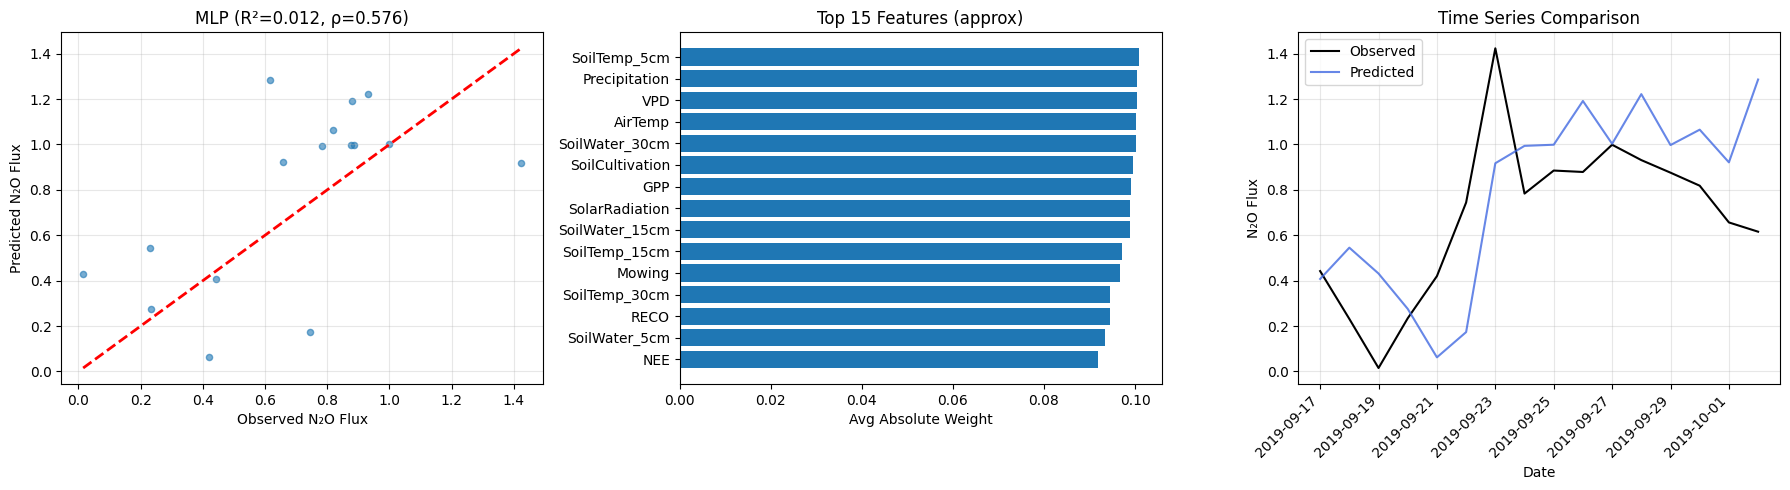


--- DAILY | target=N2O_Flux_ln | predictors=LAG ---
Train period: 2018-07-12 00:00:00 → 2019-08-30 00:00:00
Test  period: 2019-08-31 00:00:00 → 2019-10-04 00:00:00

Training MLP...
Training stopped at iteration: 33

Model evaluation:
  R² (linear scale): -0.660
  Spearman ρ:        0.136


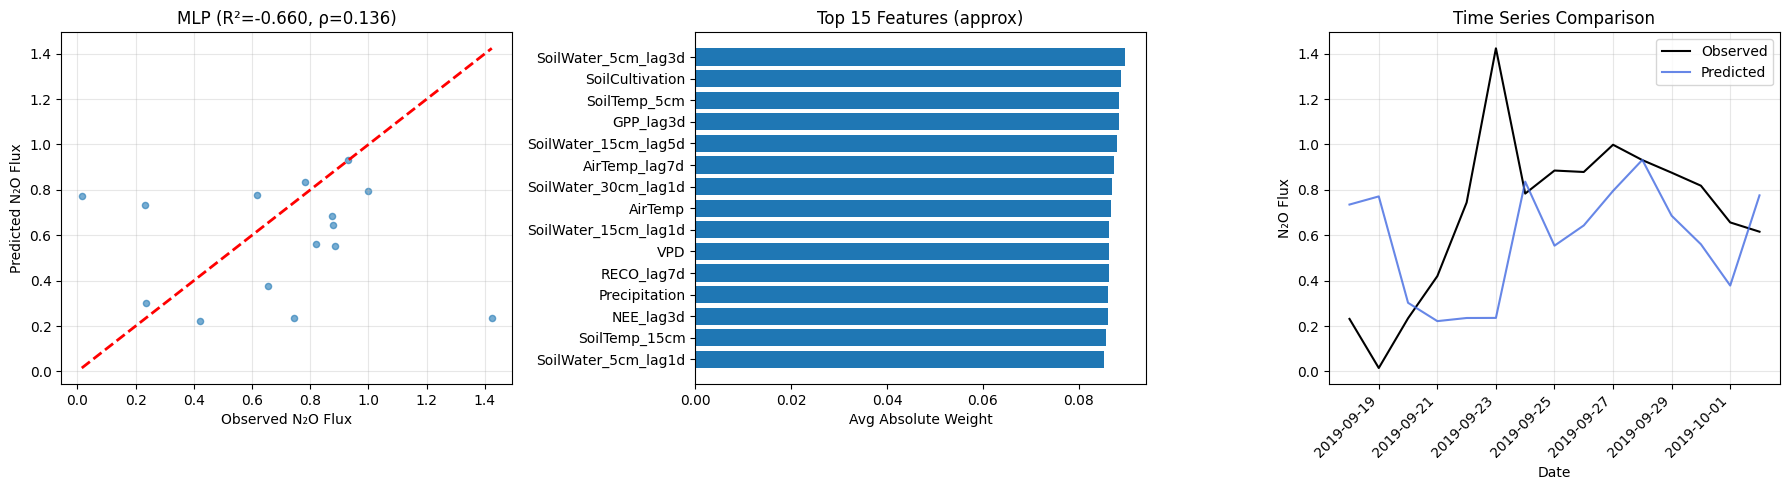


--- DAILY | target=N2O_Flux_ln | predictors=AUGMENTED ---
Train period: 2018-07-12 00:00:00 → 2019-08-30 00:00:00
Test  period: 2019-08-31 00:00:00 → 2019-10-04 00:00:00

Training MLP...
Training stopped at iteration: 63

Model evaluation:
  R² (linear scale): -0.017
  Spearman ρ:        0.364


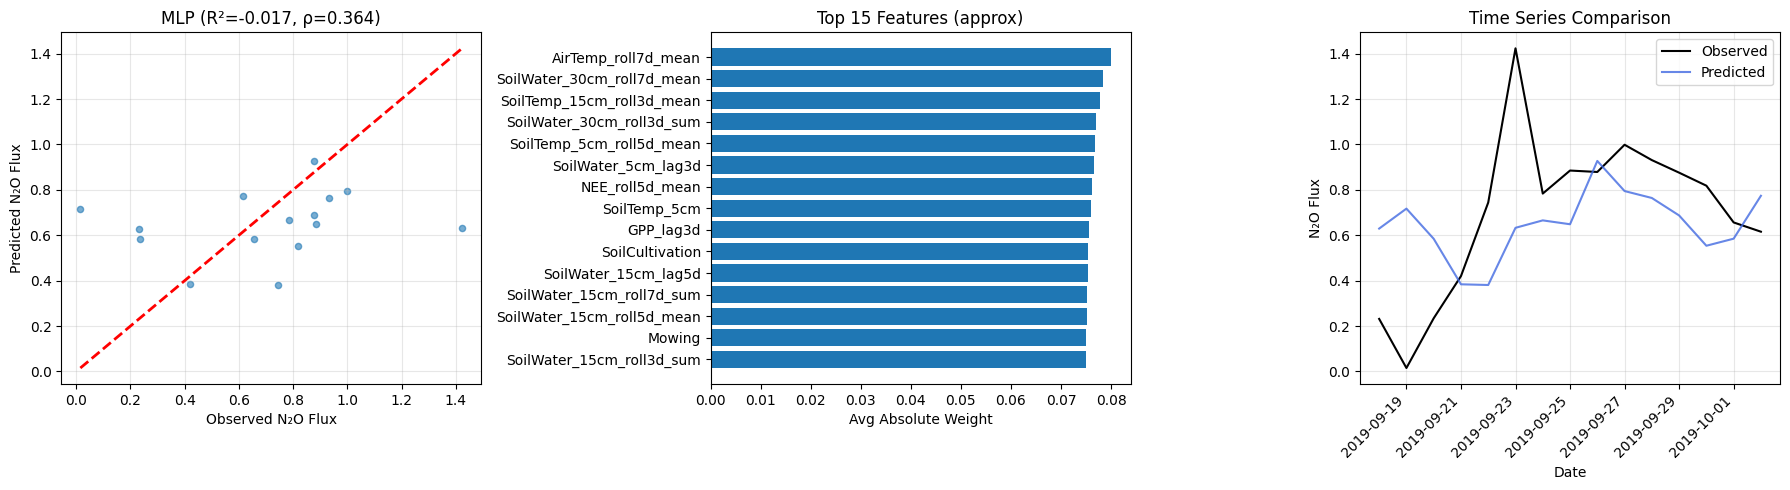


COMPREHENSIVE COMPARISON OF ALL EXPERIMENTS:
Temporal     Predictors   R²       Spearman ρ  
--------------------------------------------------------------------------------
Hourly       Base          0.213        0.547
Hourly       Lag          -0.004        0.640
Hourly       Augmented     0.203        0.650
Daily        Base          0.012        0.576
Daily        Lag          -0.660        0.136
Daily        Augmented    -0.017        0.364

IMPROVEMENT FROM BASE TO LAG:
Hourly: R² + -0.216, ρ +  0.093
Daily:  R² + -0.672, ρ + -0.441

IMPROVEMENT FROM LAG TO AUGMENTED:
Hourly: R² +  0.207, ρ +  0.011
Daily:  R² +  0.643, ρ +  0.229


In [52]:
# ============================================================================
# OENSINGEN 1
# ============================================================================

print("="*80)
print("EXPERIMENT 6: Oensingen 2018-2019")
print("="*80)

# Define base and lag predictors
base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    "Mowing", "SoilCultivation",
]

hourly_lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilWater_30cm_lag1d_daily", "SoilWater_30cm_lag3d_daily", "SoilWater_30cm_lag5d_daily", "SoilWater_30cm_lag7d_daily",
    "SoilTemp_5cm_lag1d_daily", "SoilTemp_5cm_lag3d_daily", "SoilTemp_5cm_lag5d_daily", "SoilTemp_5cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "SoilTemp_30cm_lag1d_daily", "SoilTemp_30cm_lag3d_daily", "SoilTemp_30cm_lag5d_daily", "SoilTemp_30cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",

    # --- Management variables ---
    "Mowing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_SoilCultivation"
]

hourly_augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilWater_30cm_lag1d_daily", "SoilWater_30cm_lag3d_daily", "SoilWater_30cm_lag5d_daily", "SoilWater_30cm_lag7d_daily",
    "SoilTemp_5cm_lag1d_daily", "SoilTemp_5cm_lag3d_daily", "SoilTemp_5cm_lag5d_daily", "SoilTemp_5cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "SoilTemp_30cm_lag1d_daily", "SoilTemp_30cm_lag3d_daily", "SoilTemp_30cm_lag5d_daily", "SoilTemp_30cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # Management events and days since
    "Mowing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_SoilCultivation"
]

daily_lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",

    # --- Management variables ---
    "Mowing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_SoilCultivation"
]

daily_augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilWater_30cm", "SoilTemp_5cm", "SoilTemp_15cm", "SoilTemp_30cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d", "SolarRadiation_lag5d", "SolarRadiation_lag7d",
    "AirTemp_lag1d", "AirTemp_lag3d", "AirTemp_lag5d", "AirTemp_lag7d",
    "VPD_lag1d", "VPD_lag3d", "VPD_lag5d", "VPD_lag7d",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d", "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d", "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d", "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d", "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d", "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d", "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",
    "Precipitation_lag1d", "Precipitation_lag3d", "Precipitation_lag5d", "Precipitation_lag7d",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll7d_mean",
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilWater_30cm_roll3d_sum", "SoilWater_30cm_roll5d_sum", "SoilWater_30cm_roll7d_sum",
    "SoilTemp_5cm_roll3d_sum", "SoilTemp_5cm_roll5d_sum", "SoilTemp_5cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "SoilTemp_30cm_roll3d_sum", "SoilTemp_30cm_roll5d_sum", "SoilTemp_30cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # Management events and days since
    "Mowing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_SoilCultivation"
]

# Store results for comparison
all_results = []

# ============================================================================
# HOURLY DATA - BASE PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=BASE ---")
print("="*80)

results_hourly_base = train_mlp_timeseries(
    df=oensingen_1_lag,
    predictors=base_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Base", results_hourly_base['r2'], results_hourly_base['spearman_rho']))


# ============================================================================
# HOURLY DATA - LAG PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=LAG ---")
print("="*80)

results_hourly_lag = train_mlp_timeseries(
    df=oensingen_1_lag,
    predictors=hourly_lag_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Lag", results_hourly_lag['r2'], results_hourly_lag['spearman_rho']))


# ============================================================================
# HOURLY DATA - AUGMENTED PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- HOURLY | target=N2O_Flux_ln | predictors=AUGMENTED ---")
print("="*80)

results_hourly_augmented = train_mlp_timeseries(
    df=oensingen_1_lag,
    predictors=hourly_augmented_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Hourly", "Augmented", results_hourly_augmented['r2'], results_hourly_augmented['spearman_rho']))

# ============================================================================
# DAILY DATA - BASE PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=BASE ---")
print("="*80)

results_daily_base = train_mlp_timeseries(
    df=oensingen_1_daily,
    predictors=base_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Base", results_daily_base['r2'], results_daily_base['spearman_rho']))

# ============================================================================
# DAILY DATA - LAG PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=LAG ---")
print("="*80)

results_daily_lag = train_mlp_timeseries(
    df=oensingen_1_daily,
    predictors=daily_lag_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Lag", results_daily_lag['r2'], results_daily_lag['spearman_rho']))


# ============================================================================
# DAILY DATA - AUGMENTED PREDICTORS
# ============================================================================
print("\n" + "="*80)
print("--- DAILY | target=N2O_Flux_ln | predictors=AUGMENTED ---")
print("="*80)

results_daily_augmented = train_mlp_timeseries(
    df=oensingen_1_daily,
    predictors=daily_augmented_predictors,
    target="N2O_Flux_ln",
    plot=True
)
all_results.append(("Daily", "Augmented", results_daily_augmented['r2'], results_daily_augmented['spearman_rho']))

# ============================================================================
# COMPREHENSIVE COMPARISON
# ============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON OF ALL EXPERIMENTS:")
print("="*80)
print(f"{'Temporal':<12} {'Predictors':<12} {'R²':<8} {'Spearman ρ':<12}")
print("-"*80)
for temp, pred, r2, rho in all_results:
    print(f"{temp:<12} {pred:<12} {r2:>6.3f}   {rho:>10.3f}")

print("\n" + "="*80)
print("IMPROVEMENT FROM BASE TO LAG:")
print("="*80)
print(f"Hourly: R² + {(results_hourly_lag['r2'] - results_hourly_base['r2']):>6.3f}, ρ + {(results_hourly_lag['spearman_rho'] - results_hourly_base['spearman_rho']):>6.3f}")
print(f"Daily:  R² + {(results_daily_lag['r2'] - results_daily_base['r2']):>6.3f}, ρ + {(results_daily_lag['spearman_rho'] - results_daily_base['spearman_rho']):>6.3f}")

print("\n" + "="*80)
print("IMPROVEMENT FROM LAG TO AUGMENTED:")
print("="*80)
print(f"Hourly: R² + {(results_hourly_augmented['r2'] - results_hourly_lag['r2']):>6.3f}, ρ + {(results_hourly_augmented['spearman_rho'] - results_hourly_lag['spearman_rho']):>6.3f}")
print(f"Daily:  R² + {(results_daily_augmented['r2'] - results_daily_lag['r2']):>6.3f}, ρ + {(results_daily_augmented['spearman_rho'] - results_daily_lag['spearman_rho']):>6.3f}")